### 1. Environment Config

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os

# Global Environment Configurations
DATA_PATH = "mnist.csv"
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

if not os.path.exists("plots"):
    os.makedirs("plots")

print("Libraries imported and configuration set.")

Libraries imported and configuration set.


### 2.Loading and Processing Data

In [3]:
def load_data_global(path, sample_size=None):
    """
    Load data and apply pre-processing
    """
    print(f"Loading data from {path}...")
    if not os.path.exists(path):
        print("Error: File not found. Please check DATA_PATH.")
        return None, None

    df = pd.read_csv(path)

    # Sample Size Adjustments
    if sample_size and len(df) > sample_size:
        df = df.sample(sample_size, random_state=42)
        print(f"Data sampled to {sample_size} rows.")

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    print(f"Data Loaded Successfully. Shape: {X.shape}")
    return X, y

# Data Loading
X_global, y_global = load_data_global(DATA_PATH, sample_size=5000)

Loading data from mnist.csv...
Data Loaded Successfully. Shape: (5000, 784)


### PCA Explore


--- Running Class-Specific PCA (Per Digit Analysis) ---
Processing Digit 0...
Processing Digit 1...
Processing Digit 2...
Processing Digit 3...
Processing Digit 4...
Processing Digit 5...
Processing Digit 6...
Processing Digit 7...
Processing Digit 8...
Processing Digit 9...


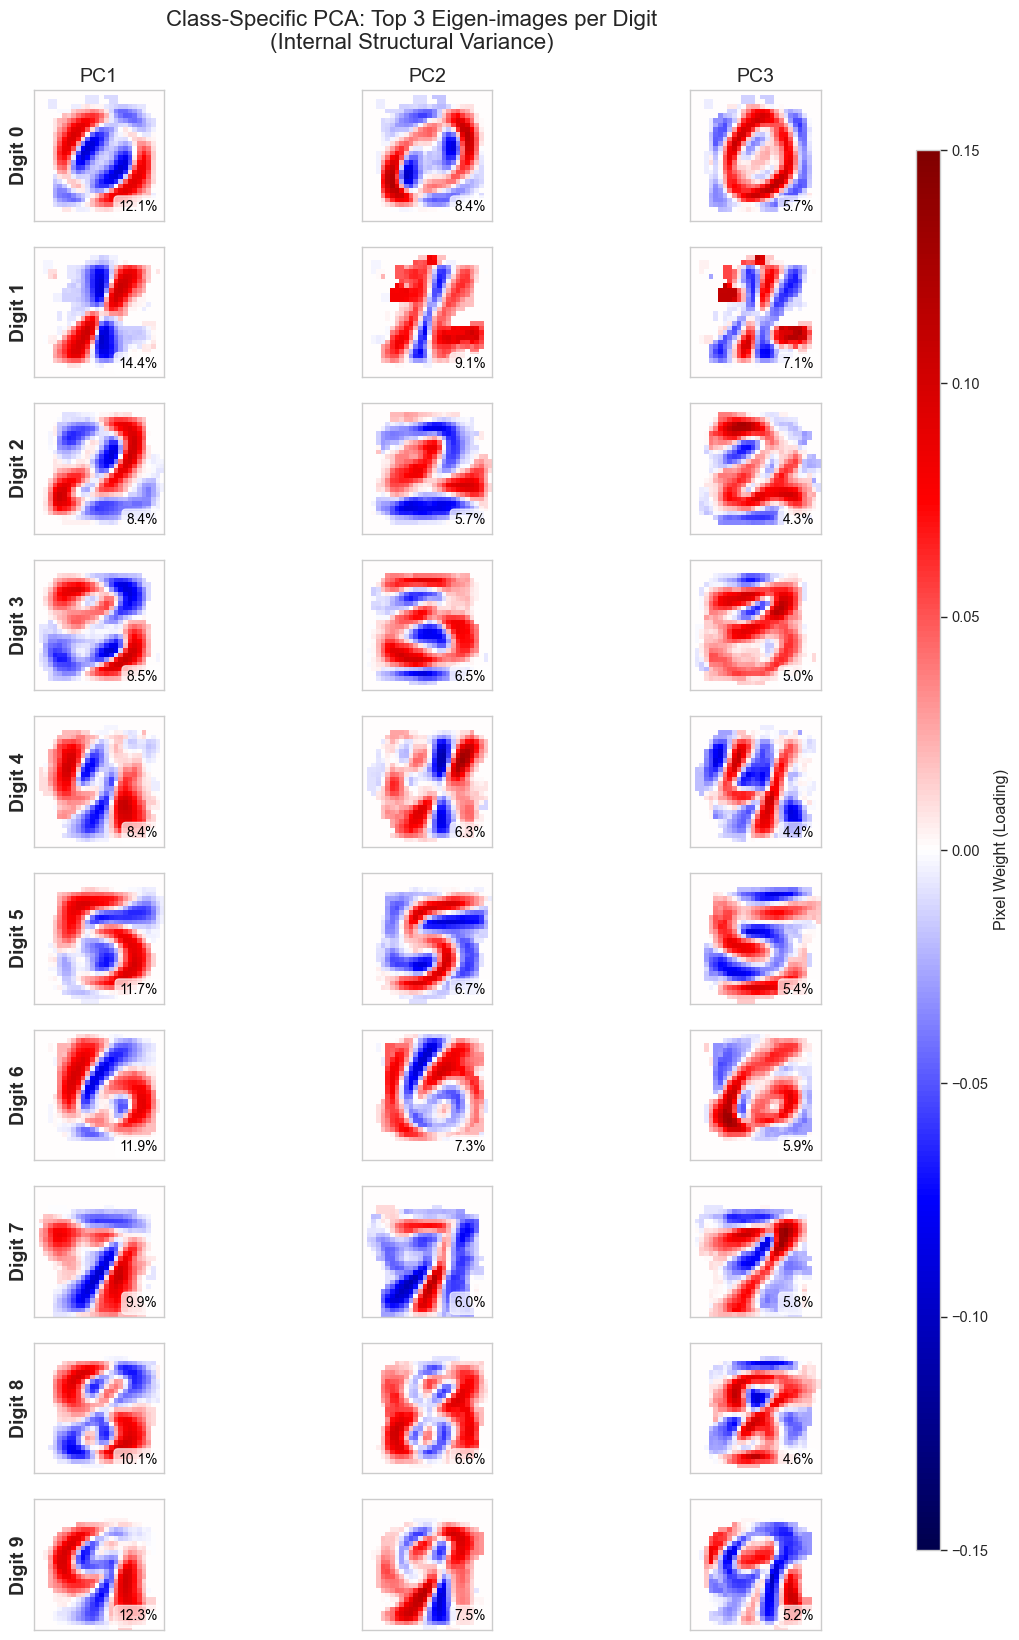

In [4]:
def visualize_class_specific_pca(X, y):
    print("\n--- Running Class-Specific PCA (Per Digit Analysis) ---")

    # 设置画布：10行 (数字0-9)，3列 (PC1-PC3)
    fig, axes = plt.subplots(10, 3, figsize=(12, 20))

    # 颜色映射设置
    cmap = 'seismic'

    # 遍历每一个数字类别
    for digit in range(10):
        print(f"Processing Digit {digit}...")

        # 1. 数据切片：只提取当前数字的样本
        X_subset = X[y == digit]

        # --- 预处理 (必须在子集内部独立进行) ---
        # 注意：某些像素在全局有方差，但在特定数字内部可能方差为0（比如边角），
        # 所以必须重新 fit VarianceThreshold 和 StandardScaler

        # 移除子集内部方差为0的像素
        selector = VarianceThreshold(threshold=0)
        X_filtered = selector.fit_transform(X_subset)

        # 标准化
        scaler = StandardScaler()
        X_std = scaler.fit_transform(X_filtered)


        pca = PCA(n_components=20, random_state=42)
        pca.fit(X_std)
        eigen_images_flat = selector.inverse_transform(pca.components_)

        # --- 绘图 ---
        for rank in range(3):
            ax = axes[digit, rank]

            # Reshape 为 28x28 图像
            img = eigen_images_flat[rank].reshape(28, 28)

            # 绘制热力图
            # vmin/vmax 设为固定范围以保证视觉上的一致性，方便对比
            im = ax.imshow(img, cmap=cmap, vmin=-0.15, vmax=0.15)

            # 获取解释方差比例
            var_ratio = pca.explained_variance_ratio_[rank]

            # 设置标签
            if rank == 0:
                ax.set_ylabel(f"Digit {digit}", fontsize=14, fontweight='bold')
            if digit == 0:
                ax.set_title(f"PC{rank+1}", fontsize=14)

            # 在图内部添加方差解释度
            ax.text(0.95, 0.05, f"{var_ratio:.1%}",
                    transform=ax.transAxes, color='black',
                    ha='right', va='bottom', fontsize=10,
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

            ax.set_xticks([])
            ax.set_yticks([])

    # 调整整体布局
    plt.suptitle("Class-Specific PCA: Top 3 Eigen-images per Digit\n(Internal Structural Variance)", fontsize=16, y=0.92)

    # 添加共用 Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Pixel Weight (Loading)')

    # plt.tight_layout() # 由于手动添加了 colorbar，通常不需要 tight_layout 或者需要小心调整
    plt.subplots_adjust(right=0.9)
    plt.show()

# --- 运行新的 PCA 分析函数 ---
# 确保 X_global 和 y_global 已经在你的环境中定义好了
visualize_class_specific_pca(X_global, y_global)

### 5. CCA Explore


--- Running Pure CCA Analysis (PC Count = 10) ---


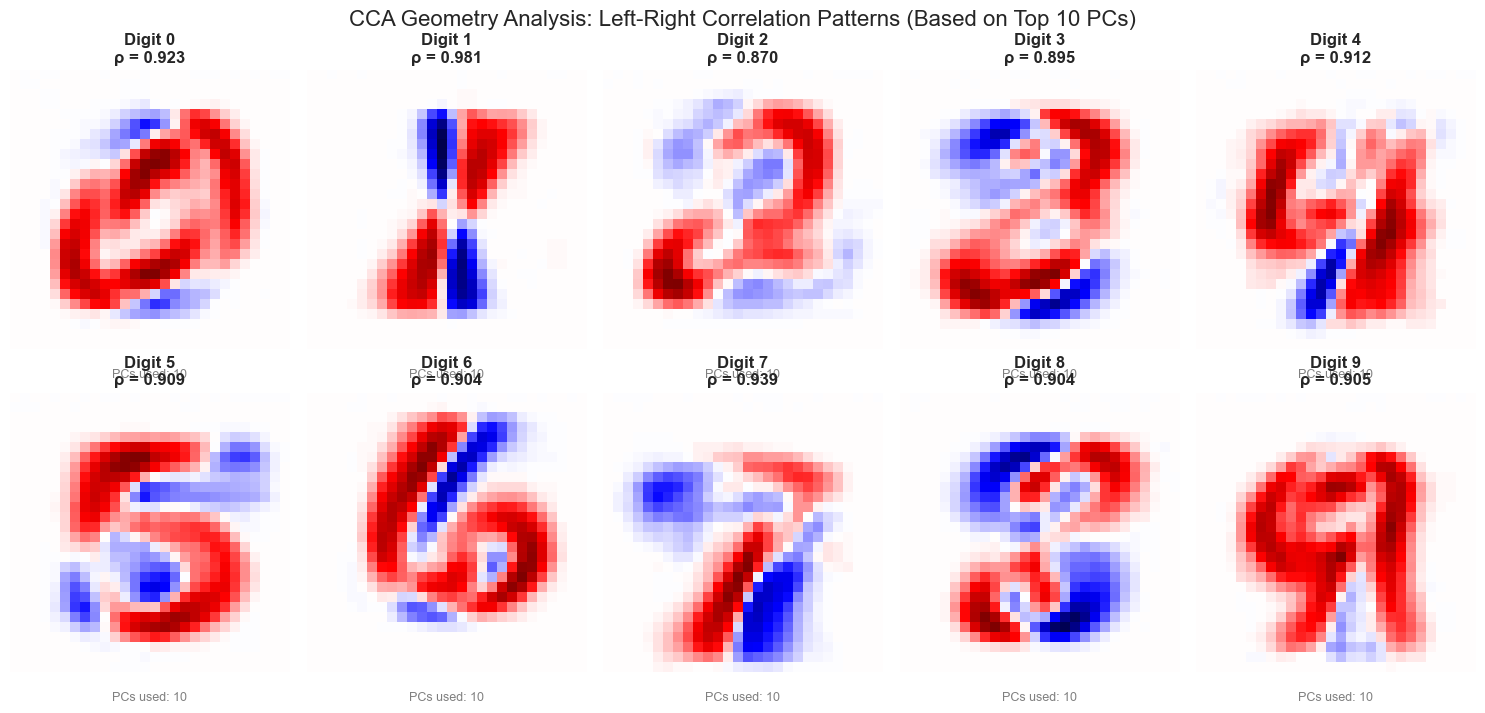

In [27]:
def visualize_pure_cca_mode(X, y):

    # ==========================================
    # [!] 这里是修改 PC 数量的地方
    # ==========================================
    N_PC_COMPONENTS = 10  # <--- 修改这个数字 (例如 10, 20, 50)
    # ==========================================

    print(f"\n--- Running Pure CCA Analysis (PC Count = {N_PC_COMPONENTS}) ---")

    IMG_SIZE = 28
    CUT_COL = 14 # 图像左右分割线

    # 设置布局：2行5列 (0-4 第一行, 5-9 第二行)
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    axes = axes.flatten() # 展平方便索引 0-9

    # 颜色映射 (红=正相关, 蓝=负相关, 白=无相关)
    cmap = 'seismic'

    for digit in range(10):
        print(f"Processing Digit {digit}...", end="\r")
        ax = axes[digit]

        # --- 1. 数据清洗 (Clean Norm) ---
        X_digit = X[y == digit]
        # 仅除以 255，不减均值不除方差，保持背景纯净
        X_norm = X_digit / 255.0
        n_samples = X_norm.shape[0]

        # --- 2. 左右切分 ---
        X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
        X_left = X_img[:, :, :CUT_COL].reshape(n_samples, -1)
        X_right = X_img[:, :, CUT_COL:].reshape(n_samples, -1)

        # --- 3. PCA 降维 (Denoising) ---
        # 使用上面定义的 N_PC_COMPONENTS
        pca_l = PCA(n_components=N_PC_COMPONENTS, random_state=42)
        pca_r = PCA(n_components=N_PC_COMPONENTS, random_state=42)

        X_l_pca = pca_l.fit_transform(X_left)
        X_r_pca = pca_r.fit_transform(X_right)

        # --- 4. CCA 关联分析 ---
        cca = CCA(n_components=1)
        cca_img = np.zeros((28, 28))
        corr = 0

        try:
            cca.fit(X_l_pca, X_r_pca)

            # 计算相关系数 rho
            U, V = cca.transform(X_l_pca, X_r_pca)
            corr = np.corrcoef(U[:, 0], V[:, 0])[0, 1]

            # 逆向投影权重 (Back-projection)
            w_l = cca.x_weights_[:, 0]
            w_r = cca.y_weights_[:, 0]

            # 权重映射回像素空间
            # pattern = Weight * Components
            pattern_l = np.dot(w_l, pca_l.components_).reshape(28, CUT_COL)
            pattern_r = np.dot(w_r, pca_r.components_).reshape(28, CUT_COL)

            # 拼接
            cca_img[:, :CUT_COL] = pattern_l
            cca_img[:, CUT_COL:] = pattern_r

        except Exception as e:
            print(f"Error on {digit}: {e}")

        # --- 5. 绘图 ---
        v_max = np.max(np.abs(cca_img)) if np.max(np.abs(cca_img)) > 0 else 1

        im = ax.imshow(cca_img, cmap=cmap, vmin=-v_max, vmax=v_max)
        ax.axis('off')

        # 标题：数字 + 相关系数
        ax.set_title(f"Digit {digit}\nρ = {corr:.3f}", fontsize=12, fontweight='bold')

        # 在图下方简单标注当前使用的 PC 数量
        ax.text(0.5, -0.1, f"PCs used: {N_PC_COMPONENTS}",
                transform=ax.transAxes, ha='center', fontsize=9, color='gray')

    plt.suptitle(f"CCA Geometry Analysis: Left-Right Correlation Patterns (Based on Top {N_PC_COMPONENTS} PCs)", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- 运行 ---
visualize_pure_cca_mode(X_global, y_global)

In [26]:
def verify_variance_coverage(X, y, n_components=15):
    print(f"--- Evidence Verification: Cumulative Variance for Top {n_components} PCs ---")

    # 准备存储结果的列表
    data = []

    IMG_SIZE = 28
    CUT_COL = 14

    # 遍历 0 到 9
    for digit in range(10):
        # 1. 提取当前数字的数据
        X_digit = X[y == digit]

        # 2. 归一化 (Clean Norm)
        X_norm = X_digit / 255.0
        n_samples = X_norm.shape[0]

        # 3. 切分左右
        X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
        X_left = X_img[:, :, :CUT_COL].reshape(n_samples, -1)  # Flatten
        X_right = X_img[:, :, CUT_COL:].reshape(n_samples, -1)  # Flatten

        # 4. 分别运行 PCA
        # 我们只关心 n_components 能解释多少方差
        pca_l = PCA(n_components=n_components, random_state=42)
        pca_l.fit(X_left)

        pca_r = PCA(n_components=n_components, random_state=42)
        pca_r.fit(X_right)

        # 5. 计算累计解释方差 (Cumulative Variance Explained)
        # explained_variance_ratio_ 是一个数组，包含每个PC解释的比例
        # np.sum 将它们加起来
        total_var_l = np.sum(pca_l.explained_variance_ratio_)
        total_var_r = np.sum(pca_r.explained_variance_ratio_)

        data.append({
            "Digit": digit,
            "Left Variance": f"{total_var_l:.2%}",
            "Right Variance": f"{total_var_r:.2%}",
            # 保存数值以便后续检查平均值
            "L_val": total_var_l,
            "R_val": total_var_r
        })

    # 转换为 DataFrame 展示表格
    df_results = pd.DataFrame(data)

    # 计算所有数字的平均值
    avg_l = df_results["L_val"].mean()
    avg_r = df_results["R_val"].mean()

    # 移除临时的数值列，只保留格式化后的字符串
    display_df = df_results.drop(columns=["L_val", "R_val"])

    print("\nTable: Cumulative Variance Explained (PVE) by Top 20 PCs")
    print(display_df.to_markdown(index=False))  # Markdown格式打印，美观

    print("\n--- Summary Statistics ---")
    print(f"Average Variance Explained (Left):  {avg_l:.2%}")
    print(f"Average Variance Explained (Right): {avg_r:.2%}")

    # 简单的逻辑判断
    threshold = 0.80
    if avg_l > threshold and avg_r > threshold:
        print(
            f"\n[CONCLUSION] Hypothesis Confirmed: Top {n_components} PCs capture >{threshold:.0%} of the information.")
    else:
        print(f"\n[CONCLUSION] Hypothesis Weak: Top {n_components} PCs might not be enough.")


# --- 运行验证 ---
verify_variance_coverage(X_global, y_global, n_components=10)

--- Evidence Verification: Cumulative Variance for Top 10 PCs ---

Table: Cumulative Variance Explained (PVE) by Top 20 PCs
|   Digit | Left Variance   | Right Variance   |
|--------:|:----------------|:-----------------|
|       0 | 75.39%          | 71.36%           |
|       1 | 83.23%          | 81.63%           |
|       2 | 63.89%          | 64.15%           |
|       3 | 62.43%          | 66.54%           |
|       4 | 69.73%          | 67.13%           |
|       5 | 62.80%          | 68.50%           |
|       6 | 75.10%          | 66.17%           |
|       7 | 69.65%          | 71.14%           |
|       8 | 64.44%          | 59.81%           |
|       9 | 73.91%          | 67.53%           |

--- Summary Statistics ---
Average Variance Explained (Left):  70.06%
Average Variance Explained (Right): 68.39%

[CONCLUSION] Hypothesis Weak: Top 10 PCs might not be enough.


# Up / Down PCA and CCA


=== Running Top-Bottom Split Experiment (PCs=10) ===
Processing Digit 9...

Table: Cumulative Variance Explained (Top vs Bottom Split)
|   Digit | Top Variance   | Bottom Variance   |
|--------:|:---------------|:------------------|
|       0 | 70.83%         | 74.69%            |
|       1 | 83.41%         | 82.55%            |
|       2 | 68.81%         | 61.55%            |
|       3 | 64.31%         | 65.39%            |
|       4 | 69.24%         | 67.95%            |
|       5 | 67.97%         | 65.39%            |
|       6 | 75.34%         | 66.83%            |
|       7 | 68.41%         | 74.10%            |
|       8 | 62.16%         | 62.72%            |
|       9 | 69.88%         | 72.26%            |

--- Summary Statistics ---
Average Variance Explained (Top):    70.04%
Average Variance Explained (Bottom): 69.34%


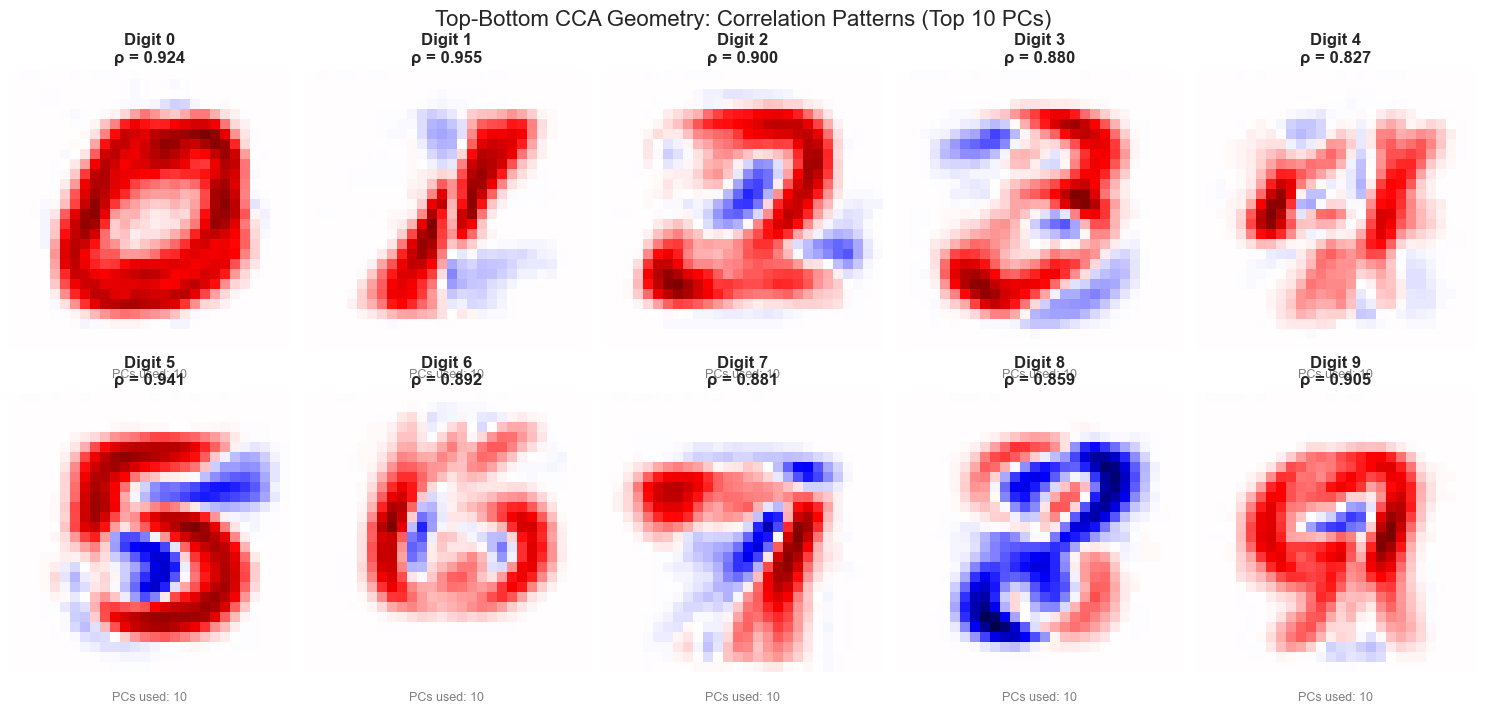

In [25]:
def run_top_bottom_experiment(X, y, n_components=15):
    # ==========================================
    # 参数设置
    # ==========================================
    print(f"\n=== Running Top-Bottom Split Experiment (PCs={n_components}) ===")

    IMG_SIZE = 28
    CUT_ROW = 14  # 水平切割点：0-13行为上部，14-27行为下部

    # 准备存储表格数据
    table_data = []

    # 准备绘图画布 (2行5列)
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    axes = axes.flatten()
    cmap = 'seismic'

    # ==========================================
    # 循环处理每个数字 0-9
    # ==========================================
    for digit in range(10):
        print(f"Processing Digit {digit}...", end="\r")

        # --- 1. 数据准备 (Data Prep) ---
        X_digit = X[y == digit]
        # 保持背景纯净的归一化
        X_norm = X_digit / 255.0
        n_samples = X_norm.shape[0]

        # 还原为图像矩阵 (N, 28, 28)
        X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

        # --- 2. 上下切割 (Top-Bottom Split) ---
        # Top: 取前 14 行 (Row 0-13)，所有列
        X_top = X_img[:, :CUT_ROW, :].reshape(n_samples, -1)
        # Bottom: 取后 14 行 (Row 14-27)，所有列
        X_bottom = X_img[:, CUT_ROW:, :].reshape(n_samples, -1)

        # --- 3. PCA 降维 (Independent PCA) ---
        pca_t = PCA(n_components=n_components, random_state=42)
        pca_b = PCA(n_components=n_components, random_state=42)

        X_t_pca = pca_t.fit_transform(X_top)
        X_b_pca = pca_b.fit_transform(X_bottom)

        # --- 4. 收集方差数据 (Variance Table Report) ---
        var_t = np.sum(pca_t.explained_variance_ratio_)
        var_b = np.sum(pca_b.explained_variance_ratio_)

        table_data.append({
            "Digit": digit,
            "Top Variance": f"{var_t:.2%}",
            "Bottom Variance": f"{var_b:.2%}",
            "T_val": var_t, # 用于后续算平均值
            "B_val": var_b
        })

        # --- 5. CCA 关联分析 (Correlation) ---
        cca = CCA(n_components=1)
        cca_img = np.zeros((IMG_SIZE, IMG_SIZE))
        corr = 0

        try:
            cca.fit(X_t_pca, X_b_pca)

            # 计算相关系数 rho
            U, V = cca.transform(X_t_pca, X_b_pca)
            corr = np.corrcoef(U[:, 0], V[:, 0])[0, 1]

            # 逆向投影 (Back-projection)
            w_t = cca.x_weights_[:, 0]
            w_b = cca.y_weights_[:, 0]

            # 还原形状：Top是 (14, 28), Bottom是 (14, 28)
            pattern_t = np.dot(w_t, pca_t.components_).reshape(CUT_ROW, 28)
            pattern_b = np.dot(w_b, pca_b.components_).reshape(IMG_SIZE - CUT_ROW, 28)

            # 上下拼接
            cca_img[:CUT_ROW, :] = pattern_t
            cca_img[CUT_ROW:, :] = pattern_b

        except Exception as e:
            print(f"CCA Error on {digit}: {e}")

        # --- 6. 绘图 (Plotting) ---
        ax = axes[digit]
        v_max = np.max(np.abs(cca_img)) if np.max(np.abs(cca_img)) > 0 else 1

        im = ax.imshow(cca_img, cmap=cmap, vmin=-v_max, vmax=v_max)
        ax.axis('off')
        ax.set_title(f"Digit {digit}\nρ = {corr:.3f}", fontsize=12, fontweight='bold')

        # 底部标注
        ax.text(0.5, -0.1, f"PCs used: {n_components}",
                transform=ax.transAxes, ha='center', fontsize=9, color='gray')

    # ==========================================
    # 输出报告
    # ==========================================

    # 1. 打印方差表格
    df_res = pd.DataFrame(table_data)
    avg_t = df_res["T_val"].mean()
    avg_b = df_res["B_val"].mean()

    # 整理表格列
    display_df = df_res.drop(columns=["T_val", "B_val"])

    print("\n\nTable: Cumulative Variance Explained (Top vs Bottom Split)")
    print(display_df.to_markdown(index=False))

    print("\n--- Summary Statistics ---")
    print(f"Average Variance Explained (Top):    {avg_t:.2%}")
    print(f"Average Variance Explained (Bottom): {avg_b:.2%}")

    # 2. 显示图像
    plt.suptitle(f"Top-Bottom CCA Geometry: Correlation Patterns (Top {n_components} PCs)", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- 执行 ---
# 使用你在PDF中提到的 X_global, y_global
# 参数设为 15，如你所求
run_top_bottom_experiment(X_global, y_global, n_components=10)


=== Running Top-Bottom Split Experiment (PCs=5) ===


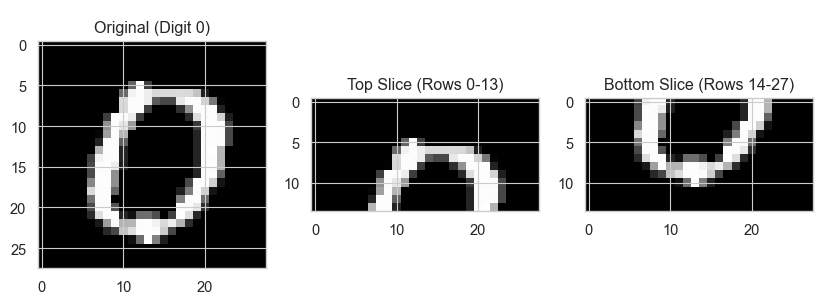

Check the plot above. If 'Top Slice' looks like a Left Slice, logic is wrong.

Processing Digit 9...

Table: Cumulative Variance Explained (Top vs Bottom Split)
|   Digit | Top Variance   | Bottom Variance   |
|--------:|:---------------|:------------------|
|       0 | 56.52%         | 59.71%            |
|       1 | 73.20%         | 71.78%            |
|       2 | 51.98%         | 43.85%            |
|       3 | 48.07%         | 48.75%            |
|       4 | 54.26%         | 53.68%            |
|       5 | 52.42%         | 49.41%            |
|       6 | 60.25%         | 48.33%            |
|       7 | 52.11%         | 60.66%            |
|       8 | 44.48%         | 45.34%            |
|       9 | 52.62%         | 56.11%            |

--- Summary Statistics ---
Average Variance Explained (Top):    54.59%
Average Variance Explained (Bottom): 53.76%


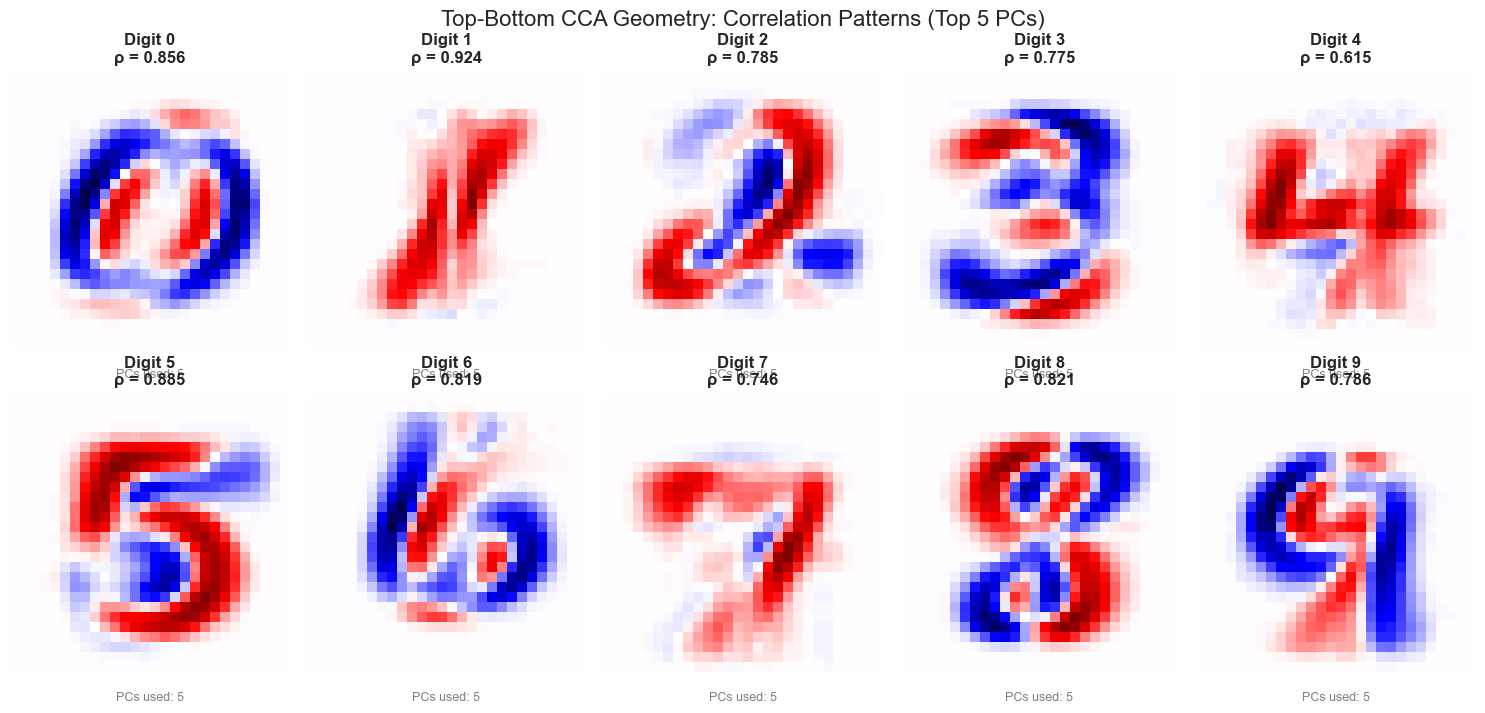

In [61]:
def run_top_bottom_experiment(X, y, n_components=5):
    # ==========================================
    # 参数设置
    # ==========================================
    print(f"\n=== Running Top-Bottom Split Experiment (PCs={n_components}) ===")

    IMG_SIZE = 28
    CUT_ROW = 14  # 水平切割点：0-13行为上部，14-27行为下部

    # ---------------------------------------------------------
    # [SANITY CHECK] 视觉验证切片逻辑
    # ---------------------------------------------------------
    # 取出一个数字 0 的样本来看看
    sample_digit = X[y == 0][0].reshape(IMG_SIZE, IMG_SIZE) / 255.0

    # 模拟切片
    sample_top = sample_digit[:CUT_ROW, :]
    sample_bottom = sample_digit[CUT_ROW:, :]

    # 绘图验证
    fig_check, ax_check = plt.subplots(1, 3, figsize=(10, 3))
    ax_check[0].imshow(sample_digit, cmap='gray')
    ax_check[0].set_title("Original (Digit 0)")

    ax_check[1].imshow(sample_top, cmap='gray')
    ax_check[1].set_title("Top Slice (Rows 0-13)")

    ax_check[2].imshow(sample_bottom, cmap='gray')
    ax_check[2].set_title("Bottom Slice (Rows 14-27)")

    plt.suptitle(" ", fontsize=14, color='red')
    plt.show()
    print("Check the plot above. If 'Top Slice' looks like a Left Slice, logic is wrong.\n")
    # ---------------------------------------------------------

    # 准备存储表格数据
    table_data = []

    # 准备绘图画布 (2行5列)
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    axes = axes.flatten()
    cmap = 'seismic'

    # ==========================================
    # 循环处理每个数字 0-9
    # ==========================================
    for digit in range(10):
        print(f"Processing Digit {digit}...", end="\r")

        # --- 1. 数据准备 (Data Prep) ---
        X_digit = X[y == digit]
        # 保持背景纯净的归一化
        X_norm = X_digit / 255.0
        n_samples = X_norm.shape[0]

        # 还原为图像矩阵 (N, 28, 28)
        X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

        # --- 2. 上下切割 (Top-Bottom Split) ---
        # 核心逻辑：使用 axis=1 (Rows) 进行切片
        # Top: 取前 14 行 (Row 0-13)，所有列
        # Shape 应该是 (N, 14, 28) -> Flatten to (N, 392)
        X_top = X_img[:, :CUT_ROW, :].reshape(n_samples, -1)

        # Bottom: 取后 14 行 (Row 14-27)，所有列
        X_bottom = X_img[:, CUT_ROW:, :].reshape(n_samples, -1)

        # --- 3. PCA 降维 (Independent PCA) ---
        pca_t = PCA(n_components=n_components, random_state=42)
        pca_b = PCA(n_components=n_components, random_state=42)

        X_t_pca = pca_t.fit_transform(X_top)
        X_b_pca = pca_b.fit_transform(X_bottom)

        # --- 4. 收集方差数据 (Variance Table Report) ---
        var_t = np.sum(pca_t.explained_variance_ratio_)
        var_b = np.sum(pca_b.explained_variance_ratio_)

        table_data.append({
            "Digit": digit,
            "Top Variance": f"{var_t:.2%}",
            "Bottom Variance": f"{var_b:.2%}",
            "T_val": var_t, # 用于后续算平均值
            "B_val": var_b
        })

        # --- 5. CCA 关联分析 (Correlation) ---
        cca = CCA(n_components=1)
        cca_img = np.zeros((IMG_SIZE, IMG_SIZE))
        corr = 0

        try:
            cca.fit(X_t_pca, X_b_pca)

            # 计算相关系数 rho
            U, V = cca.transform(X_t_pca, X_b_pca)
            corr = np.corrcoef(U[:, 0], V[:, 0])[0, 1]

            # 逆向投影 (Back-projection)
            w_t = cca.x_weights_[:, 0]
            w_b = cca.y_weights_[:, 0]

            # 还原形状：Top是 (14, 28), Bottom是 (14, 28)
            pattern_t = np.dot(w_t, pca_t.components_).reshape(CUT_ROW, 28)
            pattern_b = np.dot(w_b, pca_b.components_).reshape(IMG_SIZE - CUT_ROW, 28)

            # 上下拼接
            cca_img[:CUT_ROW, :] = pattern_t
            cca_img[CUT_ROW:, :] = pattern_b

        except Exception as e:
            print(f"CCA Error on {digit}: {e}")

        # --- 6. 绘图 (Plotting) ---
        ax = axes[digit]
        v_max = np.max(np.abs(cca_img)) if np.max(np.abs(cca_img)) > 0 else 1

        im = ax.imshow(cca_img, cmap=cmap, vmin=-v_max, vmax=v_max)
        ax.axis('off')
        ax.set_title(f"Digit {digit}\nρ = {corr:.3f}", fontsize=12, fontweight='bold')

        # 底部标注
        ax.text(0.5, -0.1, f"PCs used: {n_components}",
                transform=ax.transAxes, ha='center', fontsize=9, color='gray')

    # ==========================================
    # 输出报告
    # ==========================================

    # 1. 打印方差表格
    df_res = pd.DataFrame(table_data)
    avg_t = df_res["T_val"].mean()
    avg_b = df_res["B_val"].mean()

    # 整理表格列
    display_df = df_res.drop(columns=["T_val", "B_val"])

    print("\n\nTable: Cumulative Variance Explained (Top vs Bottom Split)")
    print(display_df.to_markdown(index=False))

    print("\n--- Summary Statistics ---")
    print(f"Average Variance Explained (Top):    {avg_t:.2%}")
    print(f"Average Variance Explained (Bottom): {avg_b:.2%}")

    # 2. 显示图像
    plt.suptitle(f"Top-Bottom CCA Geometry: Correlation Patterns (Top {n_components} PCs)", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- 执行 ---
run_top_bottom_experiment(X_global, y_global, n_components=5)


=== Generating PC1-PC5 Matrix for Digit '1' (4-Way Split) ===


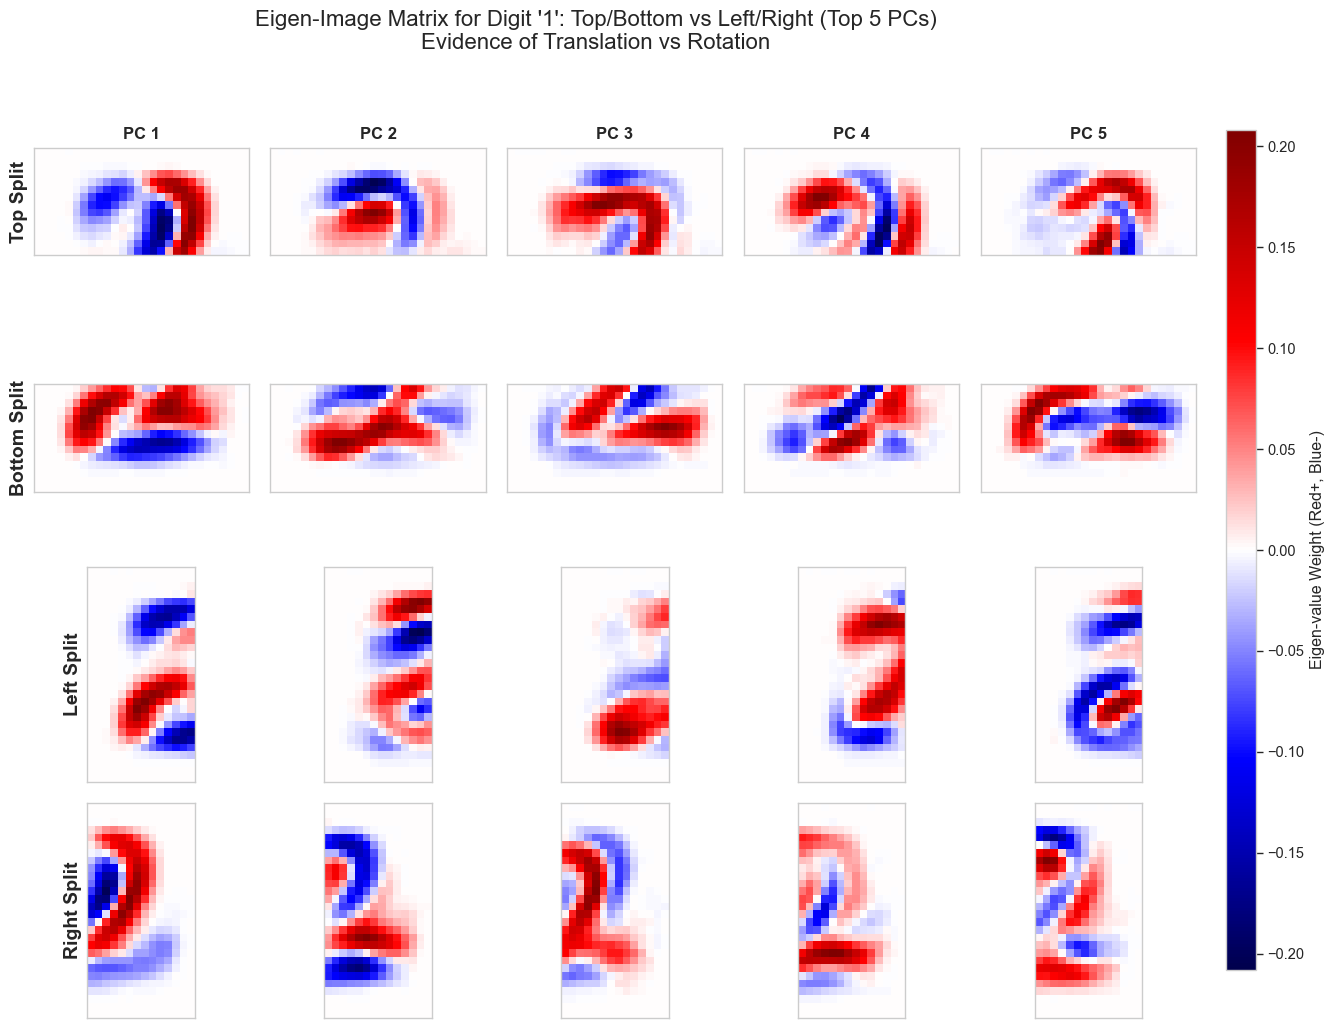

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_pc_matrix_digit_1(X, y):
    print("\n=== Generating PC1-PC5 Matrix for Digit '1' (4-Way Split) ===")

    # 1. 准备数据 (Digit 1 Only)
    X_digit = X[y == 2]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT = 14

    # 还原为图像
    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    # 2. 准备四份数据 (Four Parts)
    # Top (Row 0-13)
    X_top = X_img[:, :CUT, :].reshape(n_samples, -1)
    # Bottom (Row 14-27)
    X_bottom = X_img[:, CUT:, :].reshape(n_samples, -1)
    # Left (Col 0-13)
    X_left = X_img[:, :, :CUT].reshape(n_samples, -1)
    # Right (Col 14-27)
    X_right = X_img[:, :, CUT:].reshape(n_samples, -1)

    # 3. 训练 4 个独立的 PCA
    # 我们只需要前 5 个 PC
    n_comps = 5
    pca_t = PCA(n_components=n_comps, random_state=42).fit(X_top)
    pca_b = PCA(n_components=n_comps, random_state=42).fit(X_bottom)
    pca_l = PCA(n_components=n_comps, random_state=42).fit(X_left)
    pca_r = PCA(n_components=n_comps, random_state=42).fit(X_right)

    # 4. 绘图矩阵 (4行 x 5列)
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))

    # 定义每一行的配置
    rows_config = [
        ("Top Split", pca_t, (14, 28)),    # (Title, Model, ReshapeSize)
        ("Bottom Split", pca_b, (14, 28)),
        ("Left Split", pca_l, (28, 14)),
        ("Right Split", pca_r, (28, 14))
    ]

    cmap = 'seismic'

    for row_idx, (title, model, shape) in enumerate(rows_config):
        # 获取该模型的所有 components (shape: 5, n_features)
        components = model.components_

        for col_idx in range(n_comps):
            ax = axes[row_idx, col_idx]

            # 获取第 k 个 PC 并 reshape
            pc_img = components[col_idx].reshape(shape)

            # 为了增强对比度，我们将 vmin/vmax 设为对称
            v_max = np.max(np.abs(pc_img))

            im = ax.imshow(pc_img, cmap=cmap, vmin=-v_max, vmax=v_max)
            ax.set_xticks([])
            ax.set_yticks([])

            # 标签设置
            if row_idx == 0:
                ax.set_title(f"PC {col_idx+1}", fontsize=12, fontweight='bold')

            if col_idx == 0:
                ax.set_ylabel(title, fontsize=14, fontweight='bold', rotation=90)

    # 添加 Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Eigen-value Weight (Red+, Blue-)')

    plt.suptitle("Eigen-Image Matrix for Digit '1': Top/Bottom vs Left/Right (Top 5 PCs)\nEvidence of Translation vs Rotation", fontsize=16, y=0.95)
    plt.subplots_adjust(wspace=0.1, hspace=0.1, right=0.9)
    plt.show()

# --- 运行 ---
visualize_pc_matrix_digit_1(X_global, y_global)


=== CCA Weight Inspection for Digit 8 (Top-Bottom Split) ===

--- CCA Weight Distribution (The 'Recipe') ---
| PC_Index   |   Top_Weight |   Bottom_Weight |   Abs_Top_Strength |
|:-----------|-------------:|----------------:|-------------------:|
| PC1        |       0.9723 |          0.9940 |             0.9723 |
| PC2        |       0.2082 |          0.0654 |             0.2082 |
| PC3        |      -0.0350 |         -0.0852 |             0.0350 |
| PC4        |       0.0994 |         -0.0039 |             0.0994 |
| PC5        |      -0.0090 |          0.0206 |             0.0090 |

[Observation] The dominant component in Top half is PC1 (Weight: 0.9723)


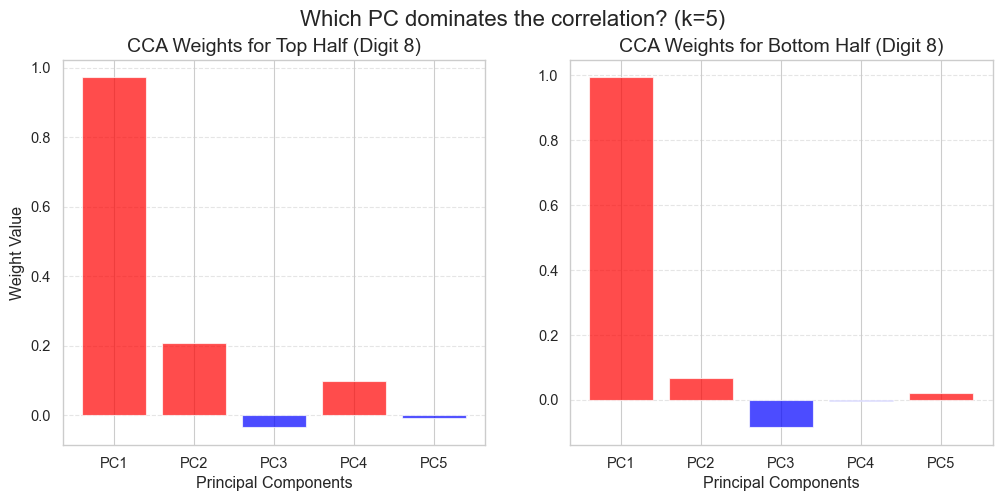

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA

def inspect_cca_weights(X, y, target_digit=2, n_components=5):
    print(f"\n=== CCA Weight Inspection for Digit {target_digit} (Top-Bottom Split) ===")

    # --- 1. 数据准备 ---
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT_ROW = 14

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
    X_top = X_img[:, :CUT_ROW, :].reshape(n_samples, -1)
    X_bottom = X_img[:, CUT_ROW:, :].reshape(n_samples, -1)

    # --- 2. PCA 降维 ---
    pca_t = PCA(n_components=n_components, random_state=42)
    pca_b = PCA(n_components=n_components, random_state=42)

    X_t_pca = pca_t.fit_transform(X_top)
    X_b_pca = pca_b.fit_transform(X_bottom)

    # --- 3. CCA 核心 ---
    cca = CCA(n_components=1)
    cca.fit(X_t_pca, X_b_pca)

    # [!] 获取权重 [!]
    # x_weights_ 对应 X_top 的权重
    # y_weights_ 对应 X_bottom 的权重
    # shape is (n_features, n_components), we want the first component
    w_top = cca.x_weights_[:, 0]
    w_bottom = cca.y_weights_[:, 0]

    # --- 4. 打印数值表格 ---
    print("\n--- CCA Weight Distribution (The 'Recipe') ---")
    df_weights = pd.DataFrame({
        "PC_Index": [f"PC{i+1}" for i in range(n_components)],
        "Top_Weight": w_top,
        "Bottom_Weight": w_bottom,
        "Abs_Top_Strength": np.abs(w_top) # 用于排序或观察绝对强度
    })

    # 打印原始数值
    print(df_weights.to_markdown(index=False, floatfmt=".4f"))

    # 找出那个“捣乱”的主导成分
    dominant_idx = np.argmax(np.abs(w_top))
    print(f"\n[Observation] The dominant component in Top half is PC{dominant_idx+1} (Weight: {w_top[dominant_idx]:.4f})")

    # --- 5. 可视化柱状图 ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 颜色：正值为红，负值为蓝
    colors_top = ['red' if x >= 0 else 'blue' for x in w_top]
    colors_bottom = ['red' if x >= 0 else 'blue' for x in w_bottom]

    x_indices = np.arange(1, n_components + 1)

    # Top Weights
    axes[0].bar(x_indices, w_top, color=colors_top, alpha=0.7)
    axes[0].set_title(f"CCA Weights for Top Half (Digit {target_digit})", fontsize=14)
    axes[0].set_xlabel("Principal Components")
    axes[0].set_ylabel("Weight Value")
    axes[0].set_xticks(x_indices)
    axes[0].set_xticklabels([f"PC{i}" for i in x_indices])
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Bottom Weights
    axes[1].bar(x_indices, w_bottom, color=colors_bottom, alpha=0.7)
    axes[1].set_title(f"CCA Weights for Bottom Half (Digit {target_digit})", fontsize=14)
    axes[1].set_xlabel("Principal Components")
    axes[1].set_xticks(x_indices)
    axes[1].set_xticklabels([f"PC{i}" for i in x_indices])
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.suptitle(f"Which PC dominates the correlation? (k={n_components})", fontsize=16)
    plt.show()

# --- 运行分析 ---
# 重点观察 PC3 和 PC4 的柱子高度
inspect_cca_weights(X_global, y_global, target_digit=8, n_components=5)


=== CCA Weight Inspection for Digit 7 (Top-Bottom Split) ===

--- CCA Weight Distribution (The 'Recipe') ---
| PC_Index   |   Top_Weight |   Bottom_Weight |   Abs_Top_Strength |
|:-----------|-------------:|----------------:|-------------------:|
| PC1        |       0.6815 |         -0.3597 |             0.6815 |
| PC2        |       0.4143 |          0.2064 |             0.4143 |
| PC3        |       0.3161 |         -0.5830 |             0.3161 |
| PC4        |      -0.1297 |          0.6506 |             0.1297 |
| PC5        |       0.4972 |          0.2547 |             0.4972 |

[Observation] The dominant component in Top half is PC1 (Weight: 0.6815)



=== CCA Weight Inspection for Digit 8 (Left-Right Split) ===

--- CCA Weight Distribution (Left-Right Split) ---
| PC_Index   |   Left_Weight |   Right_Weight |   Abs_Left_Strength |
|:-----------|--------------:|---------------:|--------------------:|
| PC1        |        0.8339 |        -0.9523 |              0.8339 |
| PC2        |       -0.2185 |        -0.1008 |              0.2185 |
| PC3        |        0.1174 |        -0.1491 |              0.1174 |
| PC4        |       -0.4903 |         0.2104 |              0.4903 |
| PC5        |        0.0524 |         0.1284 |              0.0524 |

[Observation] Dominant Left PC: PC1 (Weight: 0.8339)
[Observation] Dominant Right PC: PC1 (Weight: -0.9523)


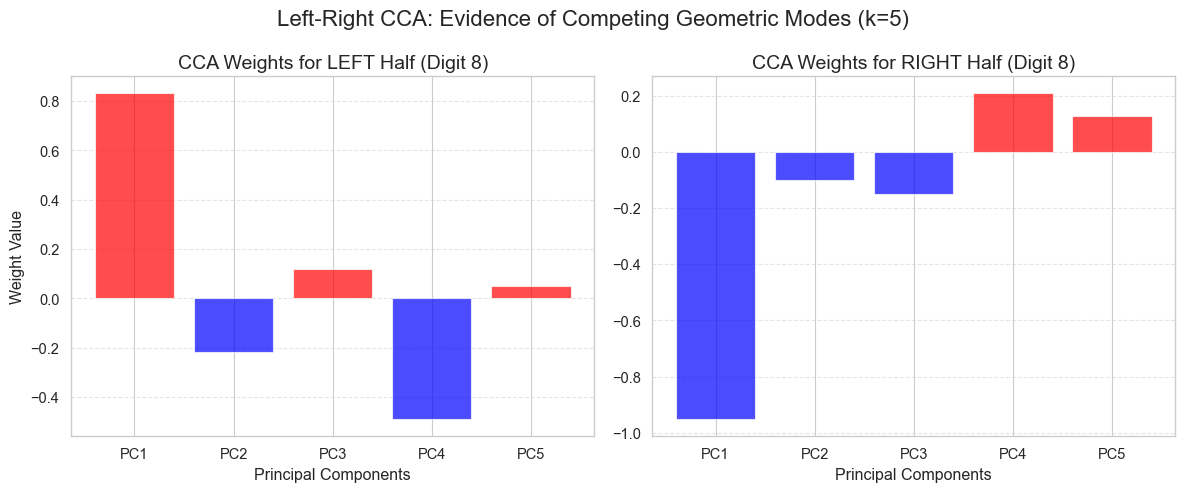

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA

def inspect_cca_weights_lr(X, y, target_digit=1, n_components=5):
    print(f"\n=== CCA Weight Inspection for Digit {target_digit} (Left-Right Split) ===")

    # --- 1. 数据准备 ---
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT_COL = 14  # 左右切割点

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    # [关键修改] 使用列切片
    # Left:  [:, :, :14]
    # Right: [:, :, 14:]
    X_left = X_img[:, :, :CUT_COL].reshape(n_samples, -1)
    X_right = X_img[:, :, CUT_COL:].reshape(n_samples, -1)

    # --- 2. PCA 降维 ---
    pca_l = PCA(n_components=n_components, random_state=42)
    pca_r = PCA(n_components=n_components, random_state=42)

    X_l_pca = pca_l.fit_transform(X_left)
    X_r_pca = pca_r.fit_transform(X_right)

    # --- 3. CCA 核心 ---
    cca = CCA(n_components=1)
    cca.fit(X_l_pca, X_r_pca)

    # [!] 获取权重 [!]
    # x_weights_ 对应 X_left
    # y_weights_ 对应 X_right
    w_left = cca.x_weights_[:, 0]
    w_right = cca.y_weights_[:, 0]

    # --- 4. 打印数值表格 ---
    print("\n--- CCA Weight Distribution (Left-Right Split) ---")
    df_weights = pd.DataFrame({
        "PC_Index": [f"PC{i+1}" for i in range(n_components)],
        "Left_Weight": w_left,
        "Right_Weight": w_right,
        "Abs_Left_Strength": np.abs(w_left)
    })

    # 打印原始数值
    print(df_weights.to_markdown(index=False, floatfmt=".4f"))

    # 找出主导成分
    dominant_idx_l = np.argmax(np.abs(w_left))
    dominant_idx_r = np.argmax(np.abs(w_right))
    print(f"\n[Observation] Dominant Left PC: PC{dominant_idx_l+1} (Weight: {w_left[dominant_idx_l]:.4f})")
    print(f"[Observation] Dominant Right PC: PC{dominant_idx_r+1} (Weight: {w_right[dominant_idx_r]:.4f})")

    # --- 5. 可视化柱状图 ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # 颜色逻辑：红色为正，蓝色为负
    colors_left = ['red' if x >= 0 else 'blue' for x in w_left]
    colors_right = ['red' if x >= 0 else 'blue' for x in w_right]

    x_indices = np.arange(1, n_components + 1)

    # Left Weights
    axes[0].bar(x_indices, w_left, color=colors_left, alpha=0.7)
    axes[0].set_title(f"CCA Weights for LEFT Half (Digit {target_digit})", fontsize=14)
    axes[0].set_xlabel("Principal Components")
    axes[0].set_ylabel("Weight Value")
    axes[0].set_xticks(x_indices)
    axes[0].set_xticklabels([f"PC{i}" for i in x_indices])
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Right Weights
    axes[1].bar(x_indices, w_right, color=colors_right, alpha=0.7)
    axes[1].set_title(f"CCA Weights for RIGHT Half (Digit {target_digit})", fontsize=14)
    axes[1].set_xlabel("Principal Components")
    axes[1].set_xticks(x_indices)
    axes[1].set_xticklabels([f"PC{i}" for i in x_indices])
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.suptitle(f"Left-Right CCA: Evidence of Competing Geometric Modes (k={n_components})", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- 运行分析 ---
# 依然针对数字 1，观察左右脑是如何“博弈”的
inspect_cca_weights_lr(X_global, y_global, target_digit=8, n_components=5)


PROCESSING DIGIT: 3

--- [Top-Bottom] Analyzing Digit 3 ---


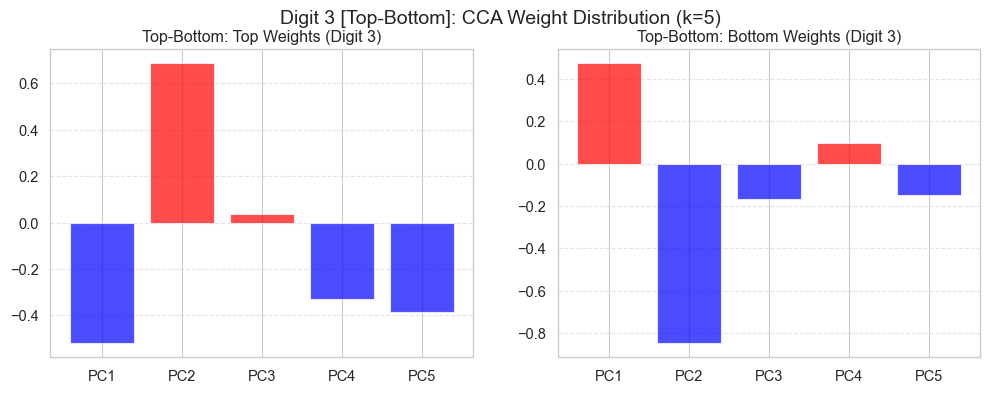


--- [Left-Right] Analyzing Digit 3 ---


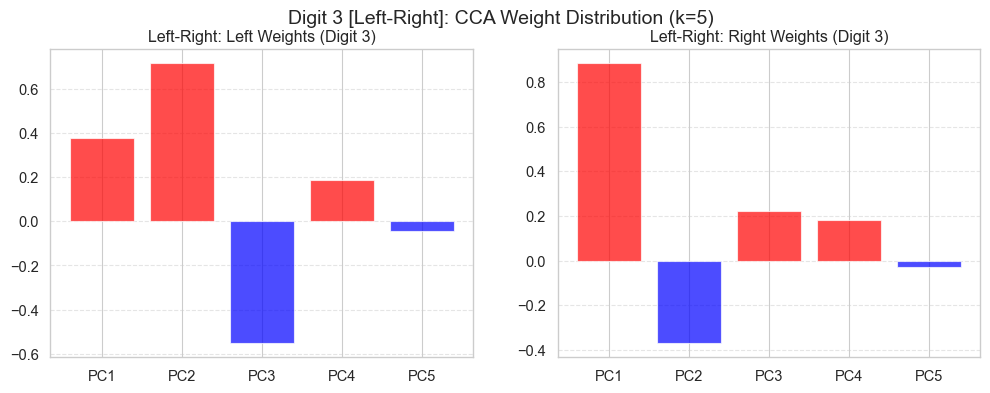


PROCESSING DIGIT: 5

--- [Top-Bottom] Analyzing Digit 5 ---


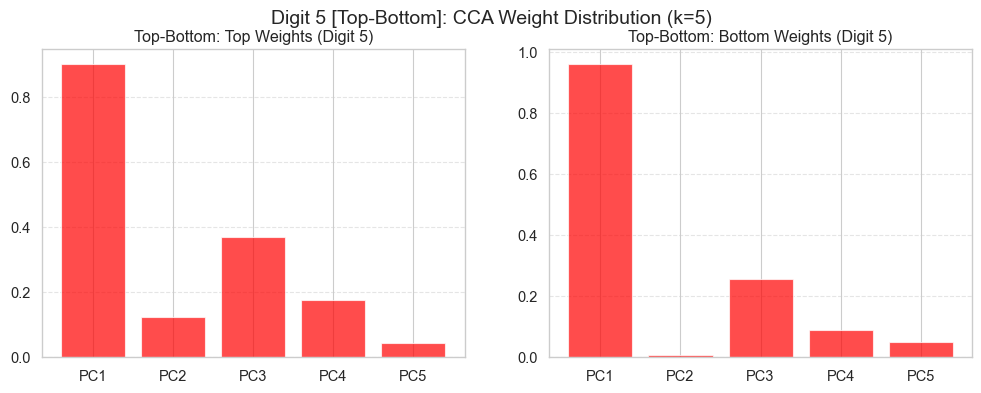


--- [Left-Right] Analyzing Digit 5 ---


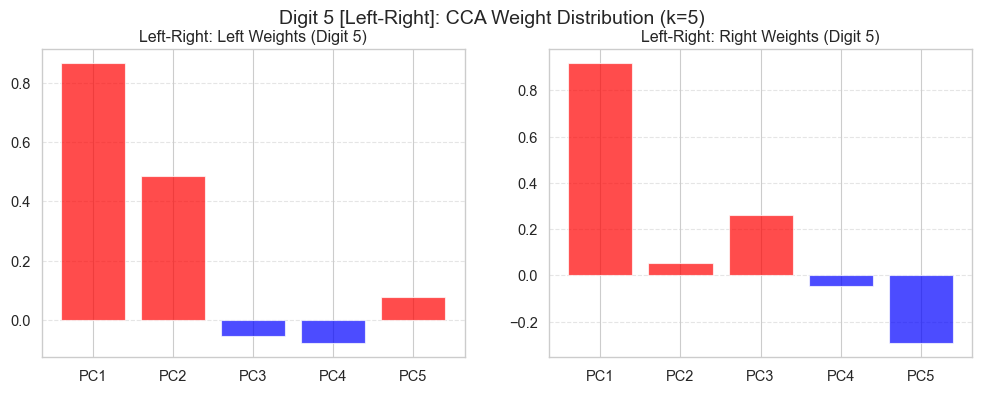

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA

# ==========================================
# 1. 定义分析函数 (Top-Bottom)
# ==========================================
def inspect_top_bottom(X, y, target_digit, n_components=5):
    print(f"\n--- [Top-Bottom] Analyzing Digit {target_digit} ---")

    # 数据准备
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]
    IMG_SIZE = 28
    CUT_ROW = 14

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
    X_top = X_img[:, :CUT_ROW, :].reshape(n_samples, -1)
    X_bottom = X_img[:, CUT_ROW:, :].reshape(n_samples, -1)

    # PCA & CCA
    pca_t = PCA(n_components=n_components, random_state=42).fit(X_top)
    pca_b = PCA(n_components=n_components, random_state=42).fit(X_bottom)

    X_t_pca = pca_t.transform(X_top)
    X_b_pca = pca_b.transform(X_bottom)

    cca = CCA(n_components=1)
    cca.fit(X_t_pca, X_b_pca)

    w_top = cca.x_weights_[:, 0]
    w_bottom = cca.y_weights_[:, 0]

    # 绘图
    plot_weights(w_top, w_bottom, target_digit, "Top-Bottom", n_components)

# ==========================================
# 2. 定义分析函数 (Left-Right)
# ==========================================
def inspect_left_right(X, y, target_digit, n_components=5):
    print(f"\n--- [Left-Right] Analyzing Digit {target_digit} ---")

    # 数据准备
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]
    IMG_SIZE = 28
    CUT_COL = 14

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
    X_left = X_img[:, :, :CUT_COL].reshape(n_samples, -1)
    X_right = X_img[:, :, CUT_COL:].reshape(n_samples, -1)

    # PCA & CCA
    pca_l = PCA(n_components=n_components, random_state=42).fit(X_left)
    pca_r = PCA(n_components=n_components, random_state=42).fit(X_right)

    X_l_pca = pca_l.transform(X_left)
    X_r_pca = pca_r.transform(X_right)

    cca = CCA(n_components=1)
    cca.fit(X_l_pca, X_r_pca)

    w_left = cca.x_weights_[:, 0]
    w_right = cca.y_weights_[:, 0]

    # 绘图
    plot_weights(w_left, w_right, target_digit, "Left-Right", n_components)

# ==========================================
# 3. 通用绘图工具
# ==========================================
def plot_weights(w1, w2, digit, mode, n_components):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x_indices = np.arange(1, n_components + 1)

    # 标签映射
    label1 = "Top" if "Top" in mode else "Left"
    label2 = "Bottom" if "Bottom" in mode else "Right"

    # 颜色
    c1 = ['red' if x >= 0 else 'blue' for x in w1]
    c2 = ['red' if x >= 0 else 'blue' for x in w2]

    # Plot 1
    axes[0].bar(x_indices, w1, color=c1, alpha=0.7)
    axes[0].set_title(f"{mode}: {label1} Weights (Digit {digit})")
    axes[0].set_xticks(x_indices)
    axes[0].set_xticklabels([f"PC{i}" for i in x_indices])
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Plot 2
    axes[1].bar(x_indices, w2, color=c2, alpha=0.7)
    axes[1].set_title(f"{mode}: {label2} Weights (Digit {digit})")
    axes[1].set_xticks(x_indices)
    axes[1].set_xticklabels([f"PC{i}" for i in x_indices])
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)

    plt.suptitle(f"Digit {digit} [{mode}]: CCA Weight Distribution (k={n_components})", fontsize=14)
    plt.show()

# ==========================================
# 4. 执行主逻辑 (Batch Run)
# ==========================================
def run_batch_analysis_3_and_5(X, y):
    targets = [3, 5]

    for digit in targets:
        print(f"\n{'='*40}")
        print(f"PROCESSING DIGIT: {digit}")
        print(f"{'='*40}")

        # 1. Top-Bottom Analysis
        inspect_top_bottom(X, y, target_digit=digit, n_components=5)

        # 2. Left-Right Analysis
        inspect_left_right(X, y, target_digit=digit, n_components=5)

# --- Run ---
run_batch_analysis_3_and_5(X_global, y_global)


=== Extracting PC1 for Digit '5' (All 4 Splits) ===


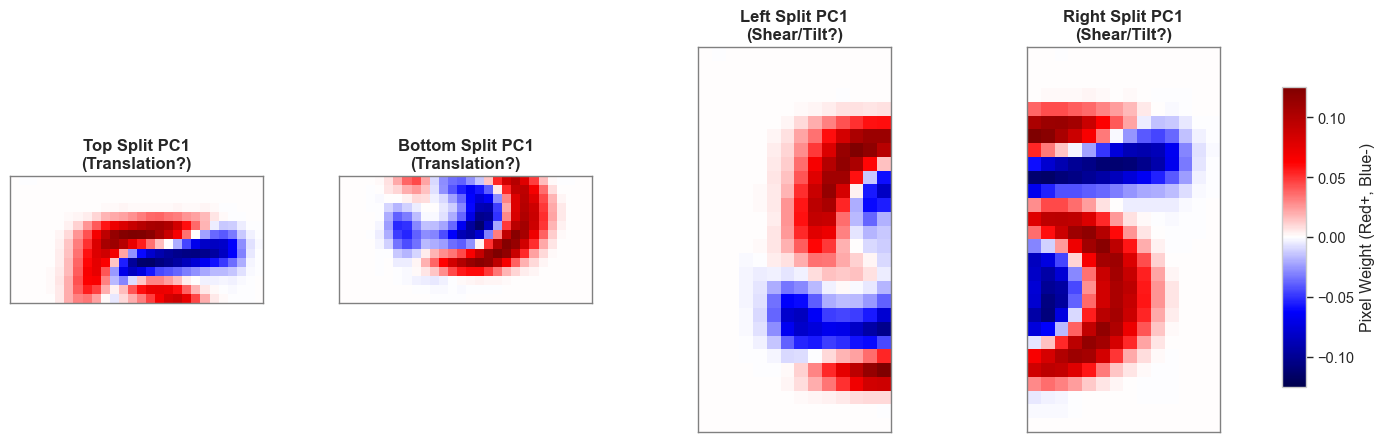

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_digit_5_pc1_only(X, y):
    print("\n=== Extracting PC1 for Digit '5' (All 4 Splits) ===")

    # 1. 数据准备 (Digit 5 Only)
    X_digit = X[y == 5]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT = 14

    # 还原为图像
    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    # 2. 准备四份数据
    # Top (Row 0-13)
    X_top = X_img[:, :CUT, :].reshape(n_samples, -1)
    # Bottom (Row 14-27)
    X_bottom = X_img[:, CUT:, :].reshape(n_samples, -1)
    # Left (Col 0-13)
    X_left = X_img[:, :, :CUT].reshape(n_samples, -1)
    # Right (Col 14-27)
    X_right = X_img[:, :, CUT:].reshape(n_samples, -1)

    # 3. 训练 4 个独立的 PCA (只取 PC1)
    pca_t = PCA(n_components=1, random_state=42).fit(X_top)
    pca_b = PCA(n_components=1, random_state=42).fit(X_bottom)
    pca_l = PCA(n_components=1, random_state=42).fit(X_left)
    pca_r = PCA(n_components=1, random_state=42).fit(X_right)

    # 4. 绘图 (1行 4列)
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))

    # 配置列表
    # (Title, Component, ReshapeSize)
    plots_config = [
        ("Top Split PC1\n(Translation?)", pca_t.components_[0], (14, 28)),
        ("Bottom Split PC1\n(Translation?)", pca_b.components_[0], (14, 28)),
        ("Left Split PC1\n(Shear/Tilt?)", pca_l.components_[0], (28, 14)),
        ("Right Split PC1\n(Shear/Tilt?)", pca_r.components_[0], (28, 14))
    ]

    cmap = 'seismic'

    for ax, (title, component, shape) in zip(axes, plots_config):
        # Reshape
        pc_img = component.reshape(shape)

        # 归一化显示范围，增强对比
        v_max = np.max(np.abs(pc_img))

        im = ax.imshow(pc_img, cmap=cmap, vmin=-v_max, vmax=v_max)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])

        # 添加边框以示区分
        for spine in ax.spines.values():
            spine.set_edgecolor('gray')
            spine.set_linewidth(1)

    # 添加 Colorbar
    cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.6])
    fig.colorbar(im, cax=cbar_ax, label='Pixel Weight (Red+, Blue-)')
    plt.subplots_adjust(wspace=0.3)
    plt.show()

# --- 运行 ---
visualize_digit_5_pc1_only(X_global, y_global)


=== CCA Weight Analysis for Digit 7 (Top-Bottom & Left-Right) ===


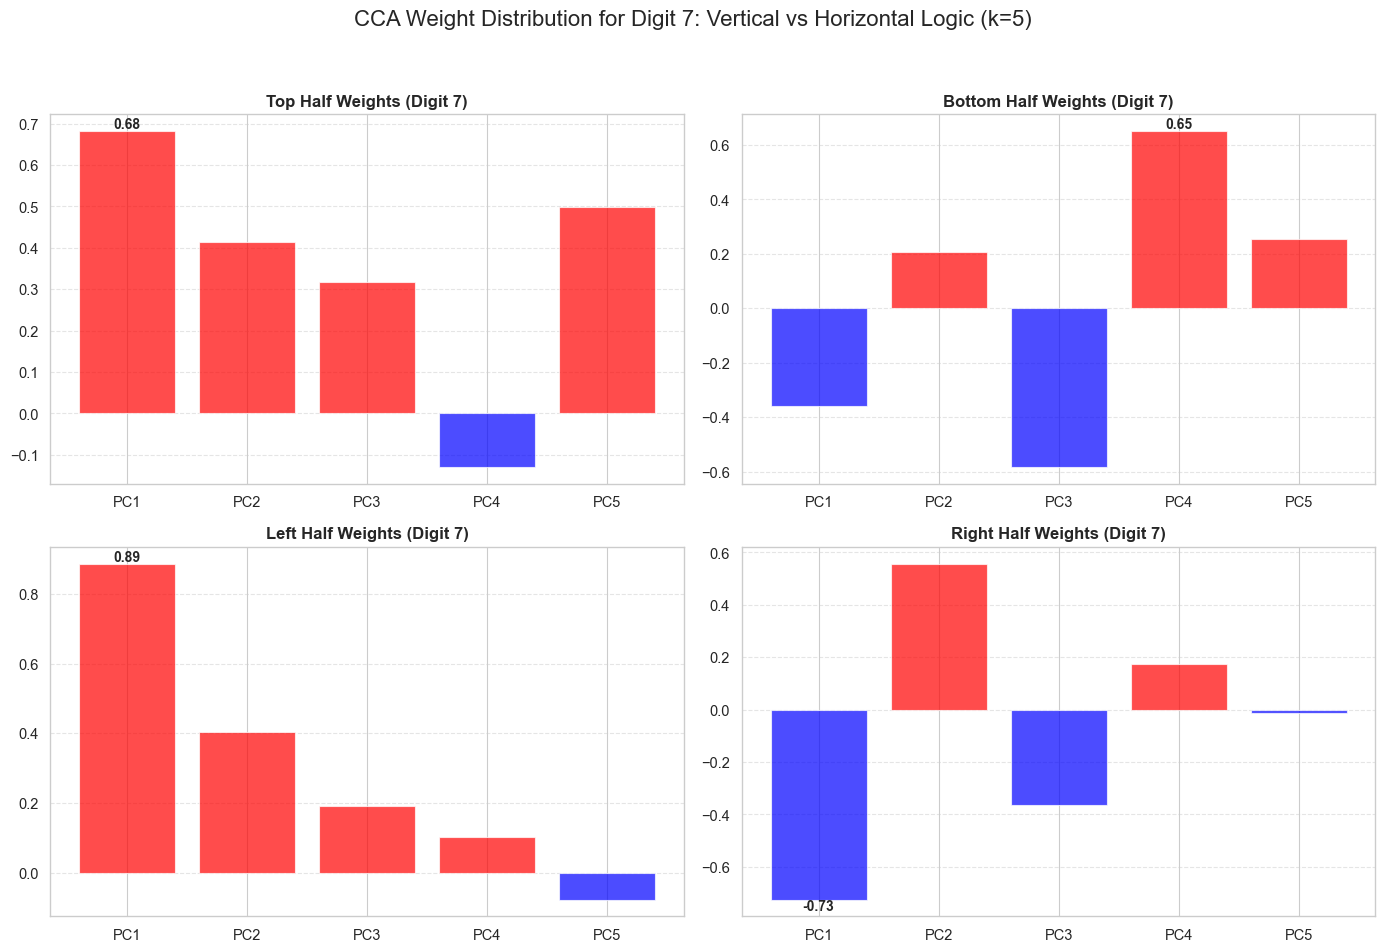

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA

def analyze_digit_6_weights(X, y, n_components=5):
    target_digit = 7
    print(f"\n=== CCA Weight Analysis for Digit {target_digit} (Top-Bottom & Left-Right) ===")

    # 1. 数据准备
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT = 14

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    # 准备切片数据
    # Top-Bottom
    X_top = X_img[:, :CUT, :].reshape(n_samples, -1)
    X_bottom = X_img[:, CUT:, :].reshape(n_samples, -1)

    # Left-Right
    X_left = X_img[:, :, :CUT].reshape(n_samples, -1)
    X_right = X_img[:, :, CUT:].reshape(n_samples, -1)

    # 2. 训练 PCA
    # Top-Bottom PCA
    pca_t = PCA(n_components=n_components, random_state=42).fit(X_top)
    pca_b = PCA(n_components=n_components, random_state=42).fit(X_bottom)
    X_t_pca = pca_t.transform(X_top)
    X_b_pca = pca_b.transform(X_bottom)

    # Left-Right PCA
    pca_l = PCA(n_components=n_components, random_state=42).fit(X_left)
    pca_r = PCA(n_components=n_components, random_state=42).fit(X_right)
    X_l_pca = pca_l.transform(X_left)
    X_r_pca = pca_r.transform(X_right)

    # 3. 运行 CCA 并提取权重
    # Top-Bottom CCA
    cca_tb = CCA(n_components=1)
    cca_tb.fit(X_t_pca, X_b_pca)
    w_top = cca_tb.x_weights_[:, 0]
    w_bottom = cca_tb.y_weights_[:, 0]

    # Left-Right CCA
    cca_lr = CCA(n_components=1)
    cca_lr.fit(X_l_pca, X_r_pca)
    w_left = cca_lr.x_weights_[:, 0]
    w_right = cca_lr.y_weights_[:, 0]

    # 4. 绘图 (2行 2列)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    x_indices = np.arange(1, n_components + 1)
    pc_labels = [f"PC{i}" for i in x_indices]

    # Helper to plot bars
    def plot_bar(ax, weights, title, color_logic=True):
        colors = ['red' if x >= 0 else 'blue' for x in weights] if color_logic else 'skyblue'
        ax.bar(x_indices, weights, color=colors, alpha=0.7)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xticks(x_indices)
        ax.set_xticklabels(pc_labels)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        # 找出主导成分
        dom_idx = np.argmax(np.abs(weights))
        ax.text(dom_idx+1, weights[dom_idx], f"{weights[dom_idx]:.2f}",
                ha='center', va='bottom' if weights[dom_idx]>0 else 'top', fontsize=10, fontweight='bold')

    # Row 1: Top-Bottom Weights
    plot_bar(axes[0, 0], w_top, f"Top Half Weights (Digit {target_digit})")
    plot_bar(axes[0, 1], w_bottom, f"Bottom Half Weights (Digit {target_digit})")

    # Row 2: Left-Right Weights
    plot_bar(axes[1, 0], w_left, f"Left Half Weights (Digit {target_digit})")
    plot_bar(axes[1, 1], w_right, f"Right Half Weights (Digit {target_digit})")

    plt.suptitle(f"CCA Weight Distribution for Digit {target_digit}: Vertical vs Horizontal Logic (k={n_components})", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 运行 ---
analyze_digit_6_weights(X_global, y_global)


=== Generating PC1-PC5 Eigen-images for Digit '6' ===


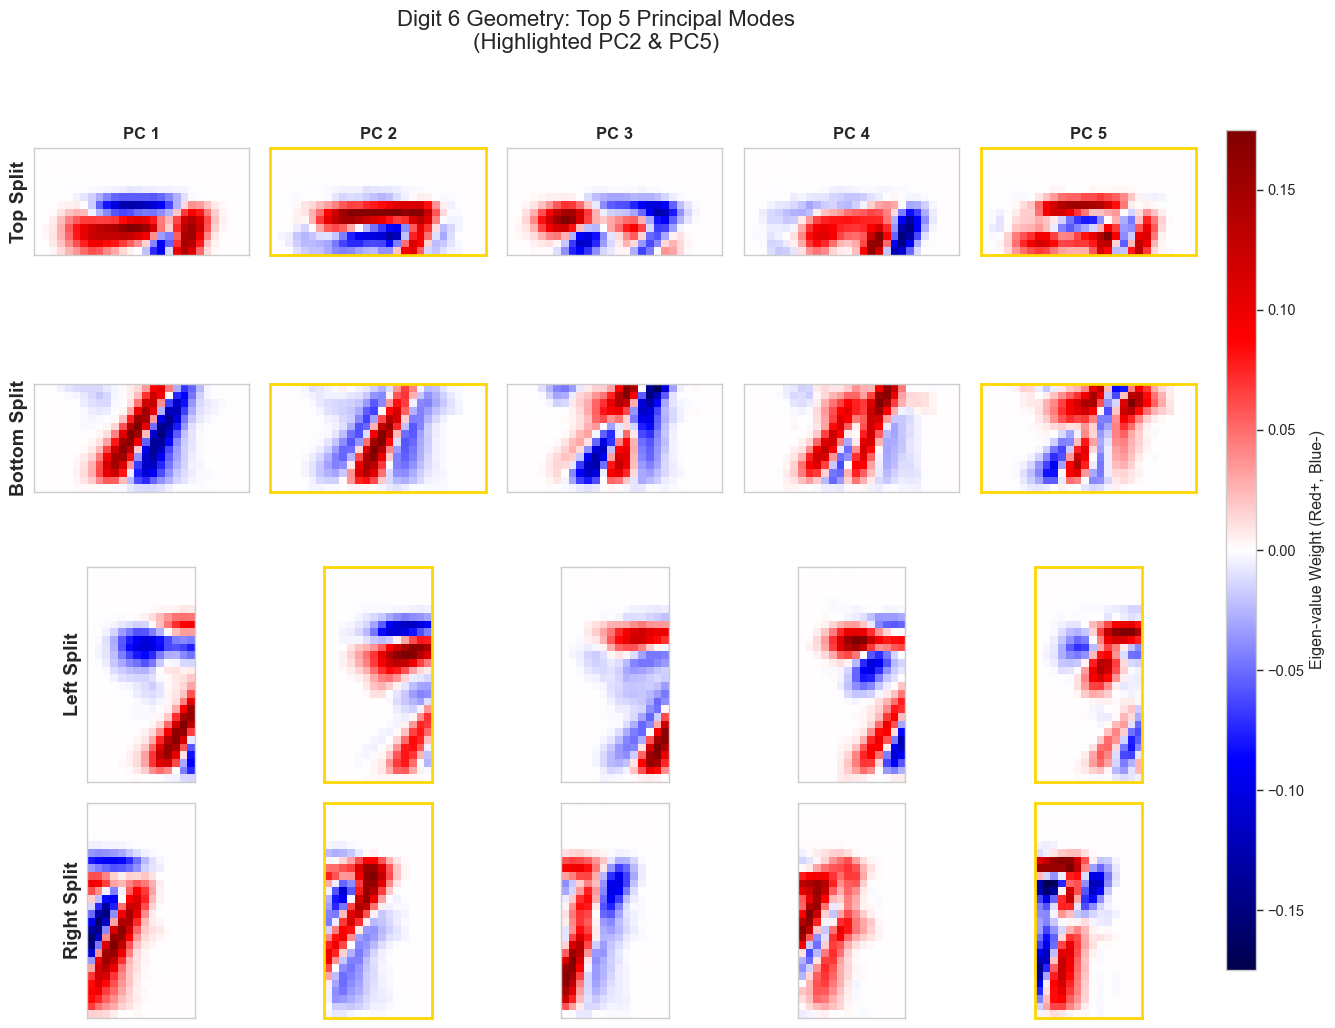

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_digit_6_pc_matrix(X, y):
    print("\n=== Generating PC1-PC5 Eigen-images for Digit '6' ===")

    # 1. 数据准备 (Digit 6 Only)
    target_digit = 7
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT = 14

    # 还原为图像
    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    # 2. 准备四份数据
    # Top (Row 0-13)
    X_top = X_img[:, :CUT, :].reshape(n_samples, -1)
    # Bottom (Row 14-27)
    X_bottom = X_img[:, CUT:, :].reshape(n_samples, -1)
    # Left (Col 0-13)
    X_left = X_img[:, :, :CUT].reshape(n_samples, -1)
    # Right (Col 14-27)
    X_right = X_img[:, :, CUT:].reshape(n_samples, -1)

    # 3. 训练 4 个独立的 PCA
    n_comps = 5
    pca_t = PCA(n_components=n_comps, random_state=42).fit(X_top)
    pca_b = PCA(n_components=n_comps, random_state=42).fit(X_bottom)
    pca_l = PCA(n_components=n_comps, random_state=42).fit(X_left)
    pca_r = PCA(n_components=n_comps, random_state=42).fit(X_right)

    # 4. 绘图矩阵 (4行 x 5列)
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))

    # 定义每一行的配置
    rows_config = [
        ("Top Split", pca_t, (14, 28)),    # (Title, Model, ReshapeSize)
        ("Bottom Split", pca_b, (14, 28)),
        ("Left Split", pca_l, (28, 14)),
        ("Right Split", pca_r, (28, 14))
    ]

    cmap = 'seismic'

    for row_idx, (title, model, shape) in enumerate(rows_config):
        # 获取该模型的所有 components
        components = model.components_

        for col_idx in range(n_comps):
            ax = axes[row_idx, col_idx]

            # 获取第 k 个 PC 并 reshape
            pc_img = components[col_idx].reshape(shape)

            # 归一化对比度
            v_max = np.max(np.abs(pc_img))

            im = ax.imshow(pc_img, cmap=cmap, vmin=-v_max, vmax=v_max)
            ax.set_xticks([])
            ax.set_yticks([])

            # 标签设置
            if row_idx == 0:
                ax.set_title(f"PC {col_idx+1}", fontsize=12, fontweight='bold')

            if col_idx == 0:
                ax.set_ylabel(title, fontsize=14, fontweight='bold', rotation=90)

            # 特别高亮用户关心的 PC2 和 PC5
            if col_idx in [1, 4]: # Index 1 is PC2, Index 4 is PC5
                for spine in ax.spines.values():
                    spine.set_edgecolor('gold')
                    spine.set_linewidth(2)

    # 添加 Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Eigen-value Weight (Red+, Blue-)')

    plt.suptitle("Digit 6 Geometry: Top 5 Principal Modes\n(Highlighted PC2 & PC5)", fontsize=16, y=0.95)
    plt.subplots_adjust(wspace=0.1, hspace=0.1, right=0.9)
    plt.show()

# --- 运行 ---
visualize_digit_6_pc_matrix(X_global, y_global)

In [56]:
def inspect_cca_7weights(X, y, target_digit=7, n_components=5):
    print(f"\n=== CCA Weight Inspection for Digit {target_digit} (Top-Bottom Split) ===")

    # --- 1. 数据准备 ---
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT_ROW = 14

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
    X_top = X_img[:, :CUT_ROW, :].reshape(n_samples, -1)
    X_bottom = X_img[:, CUT_ROW:, :].reshape(n_samples, -1)

    # --- 2. PCA 降维 ---
    pca_t = PCA(n_components=n_components, random_state=42)
    pca_b = PCA(n_components=n_components, random_state=42)

    X_t_pca = pca_t.fit_transform(X_top)
    X_b_pca = pca_b.fit_transform(X_bottom)

    # --- 3. CCA 核心 ---
    cca = CCA(n_components=1)
    cca.fit(X_t_pca, X_b_pca)

    # [!] 获取权重 [!]
    # x_weights_ 对应 X_top 的权重
    # y_weights_ 对应 X_bottom 的权重
    # shape is (n_features, n_components), we want the first component
    w_top = cca.x_weights_[:, 0]
    w_bottom = cca.y_weights_[:, 0]

    # --- 4. 打印数值表格 ---
    print("\n--- CCA Weight Distribution (The 'Recipe') ---")
    df_weights = pd.DataFrame({
        "PC_Index": [f"PC{i+1}" for i in range(n_components)],
        "Top_Weight": w_top,
        "Bottom_Weight": w_bottom,
        "Abs_Top_Strength": np.abs(w_top) # 用于排序或观察绝对强度
    })

    # 打印原始数值
    print(df_weights.to_markdown(index=False, floatfmt=".4f"))

    # 找出那个“捣乱”的主导成分
    dominant_idx = np.argmax(np.abs(w_top))
    print(f"\n[Observation] The dominant component in Top half is PC{dominant_idx+1} (Weight: {w_top[dominant_idx]:.4f})")

inspect_cca_7weights(X_global, y_global, target_digit=7, n_components=5)


=== CCA Weight Inspection for Digit 7 (Top-Bottom Split) ===

--- CCA Weight Distribution (The 'Recipe') ---
| PC_Index   |   Top_Weight |   Bottom_Weight |   Abs_Top_Strength |
|:-----------|-------------:|----------------:|-------------------:|
| PC1        |       0.6815 |         -0.3597 |             0.6815 |
| PC2        |       0.4143 |          0.2064 |             0.4143 |
| PC3        |       0.3161 |         -0.5830 |             0.3161 |
| PC4        |      -0.1297 |          0.6506 |             0.1297 |
| PC5        |       0.4972 |          0.2547 |             0.4972 |

[Observation] The dominant component in Top half is PC1 (Weight: 0.6815)


In [62]:
def inspect_cca_4weights(X, y, target_digit=7, n_components=5):
    print(f"\n=== CCA Weight Inspection for Digit {target_digit} (Top-Bottom Split) ===")

    # --- 1. 数据准备 ---
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT_ROW = 14

    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
    X_top = X_img[:, :CUT_ROW, :].reshape(n_samples, -1)
    X_bottom = X_img[:, CUT_ROW:, :].reshape(n_samples, -1)

    # --- 2. PCA 降维 ---
    pca_t = PCA(n_components=n_components, random_state=42)
    pca_b = PCA(n_components=n_components, random_state=42)

    X_t_pca = pca_t.fit_transform(X_top)
    X_b_pca = pca_b.fit_transform(X_bottom)

    # --- 3. CCA 核心 ---
    cca = CCA(n_components=1)
    cca.fit(X_t_pca, X_b_pca)

    # [!] 获取权重 [!]
    # x_weights_ 对应 X_top 的权重
    # y_weights_ 对应 X_bottom 的权重
    # shape is (n_features, n_components), we want the first component
    w_top = cca.x_weights_[:, 0]
    w_bottom = cca.y_weights_[:, 0]

    # --- 4. 打印数值表格 ---
    print("\n--- CCA Weight Distribution (The 'Recipe') ---")
    df_weights = pd.DataFrame({
        "PC_Index": [f"PC{i+1}" for i in range(n_components)],
        "Top_Weight": w_top,
        "Bottom_Weight": w_bottom,
        "Abs_Top_Strength": np.abs(w_top) # 用于排序或观察绝对强度
    })

    # 打印原始数值
    print(df_weights.to_markdown(index=False, floatfmt=".4f"))

    # 找出那个“捣乱”的主导成分
    dominant_idx = np.argmax(np.abs(w_top))
    print(f"\n[Observation] The dominant component in Top half is PC{dominant_idx+1} (Weight: {w_top[dominant_idx]:.4f})")

inspect_cca_4weights(X_global, y_global, target_digit=4, n_components=5)


=== CCA Weight Inspection for Digit 4 (Top-Bottom Split) ===

--- CCA Weight Distribution (The 'Recipe') ---
| PC_Index   |   Top_Weight |   Bottom_Weight |   Abs_Top_Strength |
|:-----------|-------------:|----------------:|-------------------:|
| PC1        |       0.5453 |          0.4088 |             0.5453 |
| PC2        |      -0.3297 |         -0.0855 |             0.3297 |
| PC3        |       0.1121 |          0.2829 |             0.1121 |
| PC4        |       0.2590 |          0.8447 |             0.2590 |
| PC5        |       0.7171 |          0.1791 |             0.7171 |

[Observation] The dominant component in Top half is PC5 (Weight: 0.7171)



=== Generating PC1-PC5 Eigen-images for Digit '6' ===


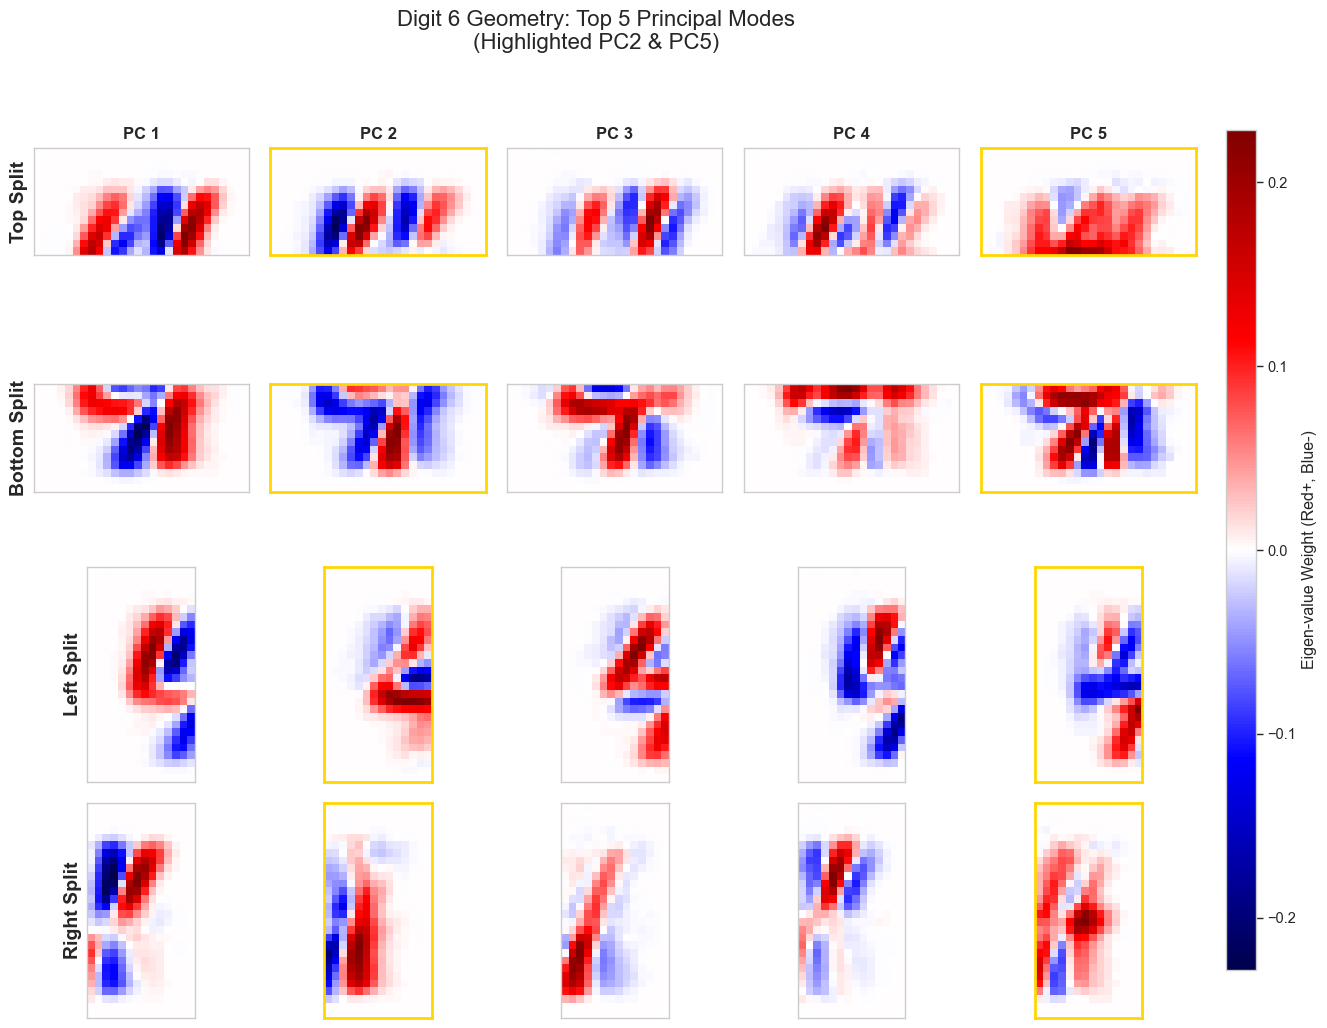

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def visualize_digit_4_pc_matrix(X, y):
    print("\n=== Generating PC1-PC5 Eigen-images for Digit '6' ===")

    # 1. 数据准备 (Digit 6 Only)
    target_digit = 4
    X_digit = X[y == target_digit]
    X_norm = X_digit / 255.0
    n_samples = X_norm.shape[0]

    IMG_SIZE = 28
    CUT = 14

    # 还原为图像
    X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)

    # 2. 准备四份数据
    # Top (Row 0-13)
    X_top = X_img[:, :CUT, :].reshape(n_samples, -1)
    # Bottom (Row 14-27)
    X_bottom = X_img[:, CUT:, :].reshape(n_samples, -1)
    # Left (Col 0-13)
    X_left = X_img[:, :, :CUT].reshape(n_samples, -1)
    # Right (Col 14-27)
    X_right = X_img[:, :, CUT:].reshape(n_samples, -1)

    # 3. 训练 4 个独立的 PCA
    n_comps = 5
    pca_t = PCA(n_components=n_comps, random_state=42).fit(X_top)
    pca_b = PCA(n_components=n_comps, random_state=42).fit(X_bottom)
    pca_l = PCA(n_components=n_comps, random_state=42).fit(X_left)
    pca_r = PCA(n_components=n_comps, random_state=42).fit(X_right)

    # 4. 绘图矩阵 (4行 x 5列)
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))

    # 定义每一行的配置
    rows_config = [
        ("Top Split", pca_t, (14, 28)),    # (Title, Model, ReshapeSize)
        ("Bottom Split", pca_b, (14, 28)),
        ("Left Split", pca_l, (28, 14)),
        ("Right Split", pca_r, (28, 14))
    ]

    cmap = 'seismic'

    for row_idx, (title, model, shape) in enumerate(rows_config):
        # 获取该模型的所有 components
        components = model.components_

        for col_idx in range(n_comps):
            ax = axes[row_idx, col_idx]

            # 获取第 k 个 PC 并 reshape
            pc_img = components[col_idx].reshape(shape)

            # 归一化对比度
            v_max = np.max(np.abs(pc_img))

            im = ax.imshow(pc_img, cmap=cmap, vmin=-v_max, vmax=v_max)
            ax.set_xticks([])
            ax.set_yticks([])

            # 标签设置
            if row_idx == 0:
                ax.set_title(f"PC {col_idx+1}", fontsize=12, fontweight='bold')

            if col_idx == 0:
                ax.set_ylabel(title, fontsize=14, fontweight='bold', rotation=90)

            # 特别高亮用户关心的 PC2 和 PC5
            if col_idx in [1, 4]: # Index 1 is PC2, Index 4 is PC5
                for spine in ax.spines.values():
                    spine.set_edgecolor('gold')
                    spine.set_linewidth(2)

    # 添加 Colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Eigen-value Weight (Red+, Blue-)')

    plt.suptitle("Digit 6 Geometry: Top 5 Principal Modes\n(Highlighted PC2 & PC5)", fontsize=16, y=0.95)
    plt.subplots_adjust(wspace=0.1, hspace=0.1, right=0.9)
    plt.show()

# --- 运行 ---
visualize_digit_4_pc_matrix(X_global, y_global)

--- Evidence Verification: Cumulative Variance for Top 20 PCs ---

Table: Cumulative Variance Explained (PVE) by Top 20 PCs
|   Digit | Left Variance   | Right Variance   |
|--------:|:----------------|:-----------------|
|       0 | 85.73%          | 83.59%           |
|       1 | 91.51%          | 90.05%           |
|       2 | 79.66%          | 79.15%           |
|       3 | 77.20%          | 81.15%           |
|       4 | 83.23%          | 80.35%           |
|       5 | 78.43%          | 82.11%           |
|       6 | 87.20%          | 80.88%           |
|       7 | 82.46%          | 83.63%           |
|       8 | 80.37%          | 76.24%           |
|       9 | 86.26%          | 81.91%           |

--- Summary Statistics ---
Average Variance Explained (Left):  83.21%
Average Variance Explained (Right): 81.91%

[CONCLUSION] Hypothesis Confirmed: Top 20 PCs capture >80% of the information.


In [8]:
def verify_variance_coverage(X, y, n_components=15):
    print(f"--- Evidence Verification: Cumulative Variance for Top {n_components} PCs ---")

    # 准备存储结果的列表
    data = []

    IMG_SIZE = 28
    CUT_COL = 14

    # 遍历 0 到 9
    for digit in range(10):
        # 1. 提取当前数字的数据
        X_digit = X[y == digit]

        # 2. 归一化 (Clean Norm)
        X_norm = X_digit / 255.0
        n_samples = X_norm.shape[0]

        # 3. 切分左右
        X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
        X_left = X_img[:, :, :CUT_COL].reshape(n_samples, -1)  # Flatten
        X_right = X_img[:, :, CUT_COL:].reshape(n_samples, -1)  # Flatten

        # 4. 分别运行 PCA
        # 我们只关心 n_components 能解释多少方差
        pca_l = PCA(n_components=n_components, random_state=42)
        pca_l.fit(X_left)

        pca_r = PCA(n_components=n_components, random_state=42)
        pca_r.fit(X_right)

        # 5. 计算累计解释方差 (Cumulative Variance Explained)
        # explained_variance_ratio_ 是一个数组，包含每个PC解释的比例
        # np.sum 将它们加起来
        total_var_l = np.sum(pca_l.explained_variance_ratio_)
        total_var_r = np.sum(pca_r.explained_variance_ratio_)

        data.append({
            "Digit": digit,
            "Left Variance": f"{total_var_l:.2%}",
            "Right Variance": f"{total_var_r:.2%}",
            # 保存数值以便后续检查平均值
            "L_val": total_var_l,
            "R_val": total_var_r
        })

    # 转换为 DataFrame 展示表格
    df_results = pd.DataFrame(data)

    # 计算所有数字的平均值
    avg_l = df_results["L_val"].mean()
    avg_r = df_results["R_val"].mean()

    # 移除临时的数值列，只保留格式化后的字符串
    display_df = df_results.drop(columns=["L_val", "R_val"])

    print("\nTable: Cumulative Variance Explained (PVE) by Top 20 PCs")
    print(display_df.to_markdown(index=False))  # Markdown格式打印，美观

    print("\n--- Summary Statistics ---")
    print(f"Average Variance Explained (Left):  {avg_l:.2%}")
    print(f"Average Variance Explained (Right): {avg_r:.2%}")

    # 简单的逻辑判断
    threshold = 0.80
    if avg_l > threshold and avg_r > threshold:
        print(
            f"\n[CONCLUSION] Hypothesis Confirmed: Top {n_components} PCs capture >{threshold:.0%} of the information.")
    else:
        print(f"\n[CONCLUSION] Hypothesis Weak: Top {n_components} PCs might not be enough.")


# --- 运行验证 ---
verify_variance_coverage(X_global, y_global, n_components=20)

--- Evidence Verification: Cumulative Variance for Top 20 PCs ---

Table: Cumulative Variance Explained (PVE) by Top 20 PCs
|   Digit | Left Variance   | Right Variance   |
|--------:|:----------------|:-----------------|
|       0 | 85.73%          | 83.59%           |
|       1 | 91.51%          | 90.05%           |
|       2 | 79.66%          | 79.15%           |
|       3 | 77.20%          | 81.15%           |
|       4 | 83.23%          | 80.35%           |
|       5 | 78.43%          | 82.11%           |
|       6 | 87.20%          | 80.88%           |
|       7 | 82.46%          | 83.63%           |
|       8 | 80.37%          | 76.24%           |
|       9 | 86.26%          | 81.91%           |

--- Summary Statistics ---
Average Variance Explained (Left):  83.21%
Average Variance Explained (Right): 81.91%

[CONCLUSION] Hypothesis Confirmed: Top 20 PCs capture >80% of the information.



--- Running Pure CCA Analysis (PC Count = 3) ---


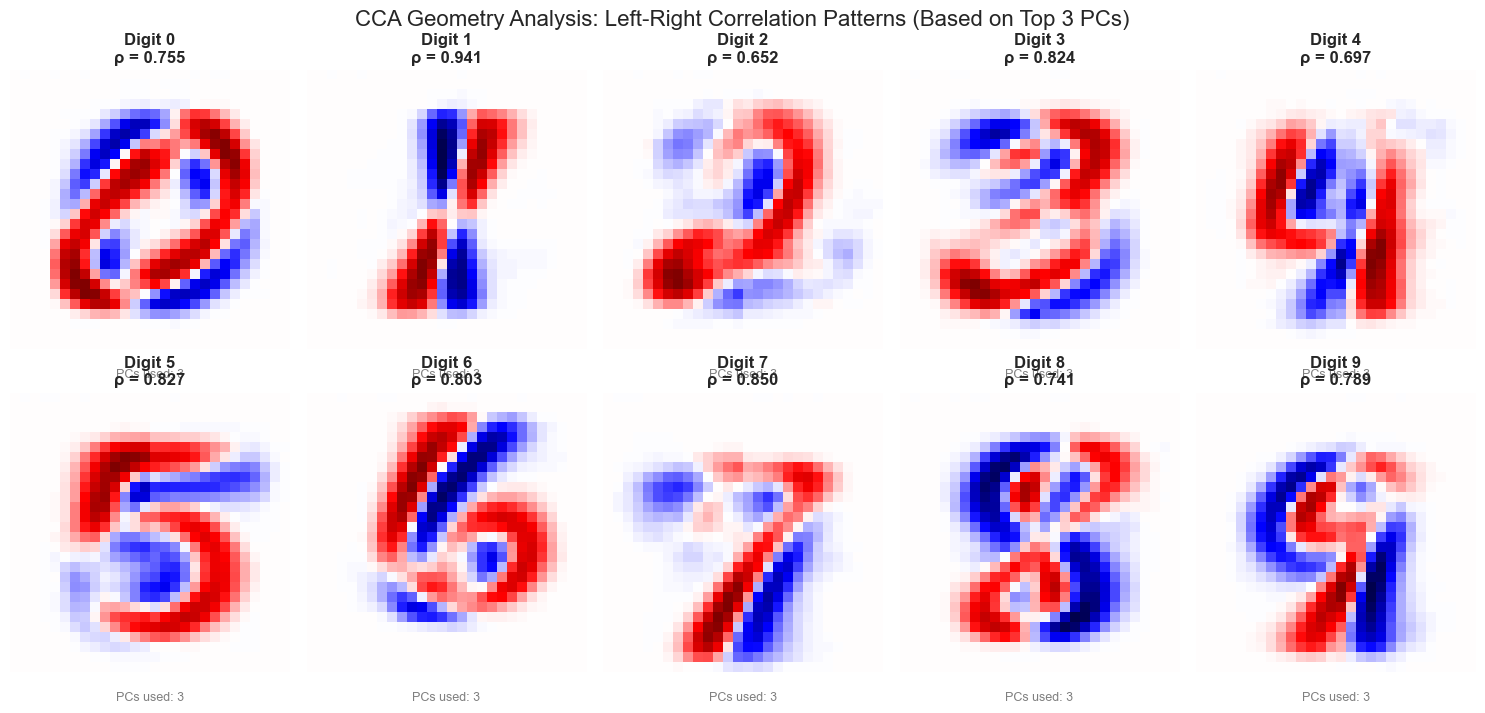

In [72]:
def visualize_pure_cca_mode(X, y):

    # ==========================================
    # [!] 这里是修改 PC 数量的地方
    # ==========================================
    N_PC_COMPONENTS = 3  # <--- 修改这个数字 (例如 10, 20, 50)
    # ==========================================

    print(f"\n--- Running Pure CCA Analysis (PC Count = {N_PC_COMPONENTS}) ---")

    IMG_SIZE = 28
    CUT_COL = 14 # 图像左右分割线

    # 设置布局：2行5列 (0-4 第一行, 5-9 第二行)
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    axes = axes.flatten() # 展平方便索引 0-9

    # 颜色映射 (红=正相关, 蓝=负相关, 白=无相关)
    cmap = 'seismic'

    for digit in range(10):
        print(f"Processing Digit {digit}...", end="\r")
        ax = axes[digit]

        # --- 1. 数据清洗 (Clean Norm) ---
        X_digit = X[y == digit]
        # 仅除以 255，不减均值不除方差，保持背景纯净
        X_norm = X_digit / 255.0
        n_samples = X_norm.shape[0]

        # --- 2. 左右切分 ---
        X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
        X_left = X_img[:, :, :CUT_COL].reshape(n_samples, -1)
        X_right = X_img[:, :, CUT_COL:].reshape(n_samples, -1)

        # --- 3. PCA 降维 (Denoising) ---
        # 使用上面定义的 N_PC_COMPONENTS
        pca_l = PCA(n_components=N_PC_COMPONENTS, random_state=42)
        pca_r = PCA(n_components=N_PC_COMPONENTS, random_state=42)

        X_l_pca = pca_l.fit_transform(X_left)
        X_r_pca = pca_r.fit_transform(X_right)

        # --- 4. CCA 关联分析 ---
        cca = CCA(n_components=1)
        cca_img = np.zeros((28, 28))
        corr = 0

        try:
            cca.fit(X_l_pca, X_r_pca)

            # 计算相关系数 rho
            U, V = cca.transform(X_l_pca, X_r_pca)
            corr = np.corrcoef(U[:, 0], V[:, 0])[0, 1]

            # 逆向投影权重 (Back-projection)
            w_l = cca.x_weights_[:, 0]
            w_r = cca.y_weights_[:, 0]

            # 权重映射回像素空间
            # pattern = Weight * Components
            pattern_l = np.dot(w_l, pca_l.components_).reshape(28, CUT_COL)
            pattern_r = np.dot(w_r, pca_r.components_).reshape(28, CUT_COL)

            # 拼接
            cca_img[:, :CUT_COL] = pattern_l
            cca_img[:, CUT_COL:] = pattern_r

        except Exception as e:
            print(f"Error on {digit}: {e}")

        # --- 5. 绘图 ---
        v_max = np.max(np.abs(cca_img)) if np.max(np.abs(cca_img)) > 0 else 1

        im = ax.imshow(cca_img, cmap=cmap, vmin=-v_max, vmax=v_max)
        ax.axis('off')

        # 标题：数字 + 相关系数
        ax.set_title(f"Digit {digit}\nρ = {corr:.3f}", fontsize=12, fontweight='bold')

        # 在图下方简单标注当前使用的 PC 数量
        ax.text(0.5, -0.1, f"PCs used: {N_PC_COMPONENTS}",
                transform=ax.transAxes, ha='center', fontsize=9, color='gray')

    plt.suptitle(f"CCA Geometry Analysis: Left-Right Correlation Patterns (Based on Top {N_PC_COMPONENTS} PCs)", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- 运行 ---
visualize_pure_cca_mode(X_global, y_global)


--- Running Pure CCA Analysis (PC Count = 3) ---


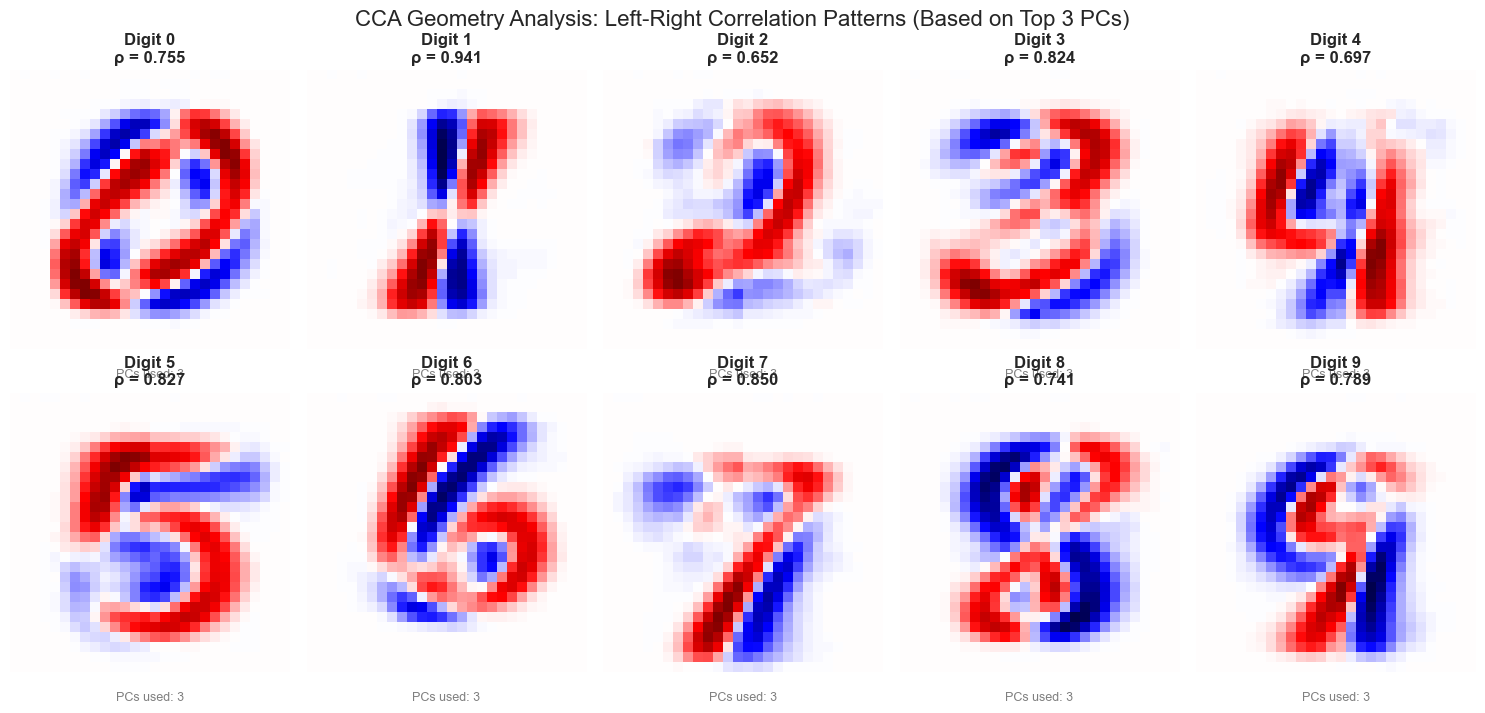

In [7]:
def visualize_pure_cca_mode(X, y):

    # ==========================================
    # [!] 这里是修改 PC 数量的地方
    # ==========================================
    N_PC_COMPONENTS = 3  # <--- 修改这个数字 (例如 10, 20, 50)
    # ==========================================

    print(f"\n--- Running Pure CCA Analysis (PC Count = {N_PC_COMPONENTS}) ---")

    IMG_SIZE = 28
    CUT_COL = 14 # 图像左右分割线

    # 设置布局：2行5列 (0-4 第一行, 5-9 第二行)
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    axes = axes.flatten() # 展平方便索引 0-9

    # 颜色映射 (红=正相关, 蓝=负相关, 白=无相关)
    cmap = 'seismic'

    for digit in range(10):
        print(f"Processing Digit {digit}...", end="\r")
        ax = axes[digit]

        # --- 1. 数据清洗 (Clean Norm) ---
        X_digit = X[y == digit]
        # 仅除以 255，不减均值不除方差，保持背景纯净
        X_norm = X_digit / 255.0
        n_samples = X_norm.shape[0]

        # --- 2. 左右切分 ---
        X_img = X_norm.reshape(n_samples, IMG_SIZE, IMG_SIZE)
        X_left = X_img[:, :, :CUT_COL].reshape(n_samples, -1)
        X_right = X_img[:, :, CUT_COL:].reshape(n_samples, -1)

        # --- 3. PCA 降维 (Denoising) ---
        # 使用上面定义的 N_PC_COMPONENTS
        pca_l = PCA(n_components=N_PC_COMPONENTS, random_state=42)
        pca_r = PCA(n_components=N_PC_COMPONENTS, random_state=42)

        X_l_pca = pca_l.fit_transform(X_left)
        X_r_pca = pca_r.fit_transform(X_right)

        # --- 4. CCA 关联分析 ---
        cca = CCA(n_components=1)
        cca_img = np.zeros((28, 28))
        corr = 0

        try:
            cca.fit(X_l_pca, X_r_pca)

            # 计算相关系数 rho
            U, V = cca.transform(X_l_pca, X_r_pca)
            corr = np.corrcoef(U[:, 0], V[:, 0])[0, 1]

            # 逆向投影权重 (Back-projection)
            w_l = cca.x_weights_[:, 0]
            w_r = cca.y_weights_[:, 0]

            # 权重映射回像素空间
            # pattern = Weight * Components
            pattern_l = np.dot(w_l, pca_l.components_).reshape(28, CUT_COL)
            pattern_r = np.dot(w_r, pca_r.components_).reshape(28, CUT_COL)

            # 拼接
            cca_img[:, :CUT_COL] = pattern_l
            cca_img[:, CUT_COL:] = pattern_r

        except Exception as e:
            print(f"Error on {digit}: {e}")

        # --- 5. 绘图 ---
        v_max = np.max(np.abs(cca_img)) if np.max(np.abs(cca_img)) > 0 else 1

        im = ax.imshow(cca_img, cmap=cmap, vmin=-v_max, vmax=v_max)
        ax.axis('off')

        # 标题：数字 + 相关系数
        ax.set_title(f"Digit {digit}\nρ = {corr:.3f}", fontsize=12, fontweight='bold')

        # 在图下方简单标注当前使用的 PC 数量
        ax.text(0.5, -0.1, f"PCs used: {N_PC_COMPONENTS}",
                transform=ax.transAxes, ha='center', fontsize=9, color='gray')

    plt.suptitle(f"CCA Geometry Analysis: Left-Right Correlation Patterns (Based on Top {N_PC_COMPONENTS} PCs)", fontsize=16)
    plt.tight_layout()
    plt.show()

# --- 运行 ---
visualize_pure_cca_mode(X_global, y_global)